## Supervised Research (Law, Economics, and Data Science)

#### Project name "Anomaly Detection for CNP Transactions".

Student: Anna Kravchenko

akravchenko@student.ethz.ch

### Part 1 - EDA

#### Goal
This notebook performs a descriptive exploratory data analysis (EDA) of financial transaction data.

The objective is to understand target behavior, transaction patterns over time, missingness structure, and key feature distributions before moving to feature audit and modeling.

*Reproducibility notes.*
- All analysis is run on the merged training dataset (train_transaction + train_identity) with a consistent `event_time` column built from `TransactionDT`. 
- When sampling is used for speed, a fixed random seed is applied to keep outputs reproducible. 
- Time-dependent plots and summaries are based on chronological ordering (no future information is used to compute past diagnostics).

## Setup

#### Imports

In [71]:
import os, gc, textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

#### Display/plot settings

In [72]:
pd.set_option("display.max_rows", 60)
pd.set_option("display.max_columns", 120)
plt.rcParams["figure.figsize"] = (10, 4)

ACCENT = "#3B5B92"     
ACCENT_DARK = "#1F3A5F"

sns.set_theme(style="whitegrid", rc={
    "axes.edgecolor": "#4A4A4A",
    "axes.labelcolor": "#2A2A2A",
    "text.color": "#2A2A2A",
    "xtick.color": "#4A4A4A",
    "ytick.color": "#4A4A4A",
    "grid.color": "#E7E7E7",
    "grid.linewidth": 0.6,
    "font.size": 11,
})
mpl.rcParams["axes.titleweight"] = "bold"
mpl.rcParams["axes.titlesize"] = 13
mpl.rcParams["figure.dpi"] = 110

#### Data load (raw tables)

In [73]:
#project paths
from pathlib import Path

#the raw IEEE-CIS files are not redistributed with this project (see README -> "Data"). 
#data link: https://www.kaggle.com/competitions/ieee-fraud-detection/data#:~:text=get_app-,Download,-All
#in order to repeat the pipeline, "Download All" and unzip the four CSVs into Data/ folder.

#my locally stored data
PROJECT_DIR = Path("/Users/kravchan/Desktop/Supervised Research/project")
DATA_DIR = PROJECT_DIR / "Data"

In [74]:
#load data
train_tr = pd.read_csv(os.path.join(DATA_DIR, "train_transaction.csv"))
train_id = pd.read_csv(os.path.join(DATA_DIR, "train_identity.csv"))

#### Initial shape prints

In [75]:
print("train_transaction:", train_tr.shape)
train_tr.head(3)

train_transaction: (590540, 394)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,...,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,F,T,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,M0,T,T,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,debit,330.0,87.0,287.0,NaN,outlook.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,315.0,NaN,NaN,NaN,315.0,T,T,T,M0,F,F,F,F,F,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [76]:
print("train_identity:", train_id.shape)
train_id.head(3)

train_identity: (144233, 41)


,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0,NotFound,NaN,-480.0,New,NotFound,166.0,NaN,542.0,144.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,Android 7.0,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,NaN,100.0,NotFound,49.0,-300.0,New,NotFound,166.0,NaN,621.0,500.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,iOS 11.1.2,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,100.0,NotFound,52.0,NaN,Found,Found,121.0,NaN,410.0,142.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Found,Found,NaN,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows


`train_transaction` includes 590,540 transactions with 394 columns, where the target isFraud, time TransactionDT, amount, card/address/email features, and engineered V-features. We can see that many V-features are mostly zeros/NaNs for these first rows.

`train_identity` includes 144,233 rows with 41 device/browser/network identity fields, with a mixture of numbers, strings, and NaNs.

Not every transaction has a matching identity row.

#### Join and sanity check
Left join on `TransactionID` keeps all transactions and attaches identity fields when available.

In [77]:
train = train_tr.merge(train_id, on = "TransactionID", how = "left")
print("joined train:", train.shape)

#% of transactions that have identity
overlap = train_tr["TransactionID"].isin(train_id["TransactionID"]).mean()
print(f"Share of transactions with identity: {overlap:.3%}")

#duplicates check by TransactionID
print("Duplicates TransactionID in transaction:", train_tr["TransactionID"].duplicated().any())
print("Duplicates TransactionID in identity:   ", train_id["TransactionID"].duplicated().any())

joined train: (590540, 434)
Share of transactions with identity: 24.424%
Duplicates TransactionID in transaction: False
Duplicates TransactionID in identity:    False


#### Dataset footprint (size, memory, data types)

In [78]:
print("Rows, cols:", train.shape)
print("\nMemory usage (MB):", round(train.memory_usage(deep=True).sum()/1e6, 2))
train.dtypes.value_counts()

Rows, cols: (590540, 434)

Memory usage (MB): 2636.09


float64    399
object      31
int64        4
Name: count, dtype: int64

This is memory-heavy, so later, when the preprocessing pipeline will be built, there will be applied the downcasting of numerics to float32/int32 and reducing high-cardinality object columns with frequency encoding.

#### Build event_time

In this dataset, `TransactionDT` is stored as elapsed seconds from a reference start date, not as a calendar timestamp.
Here it will be converted into a real datetime column called `event_time` (create `event_time` from `TransactionDT` (epoch + timedelta)) to do time-aware analysis.

`event_time` is needed for chronological train/validation/test splits, as well as for daily/weekly trend analysis and drift/stability checks over time.

In [79]:
def event_time(df, epoch = "2017-12-01"):
    if "event_time" in df.columns:
        return df  

    #possible names after merge
    tdt_candidates = [c for c in df.columns if c.startswith("TransactionDT")]
    if not tdt_candidates:
        raise KeyError(
            "Time column not found: expected 'TransactionDT' or a merged variant "
            "like 'TransactionDT_x' / 'TransactionDT_y'."
        )
    tdt = tdt_candidates[0]
    df[tdt] = pd.to_numeric(df[tdt], errors = "coerce")
    base = pd.Timestamp(epoch)
    #TransactionDT is seconds since a hidden reference date, so this turns it into a real timestamp 
    df["event_time"] = base + pd.to_timedelta(df[tdt], unit = "s")
    return df

train = event_time(train)
print("event_time ready:", "event_time" in train.columns, train["event_time"].dtype)

event_time ready: True datetime64[ns]


## Descriptive dataset story

#### Target balance

In [80]:
print("Target balance (isFraud):")
(train["isFraud"].value_counts(normalize = True) * 100).round(2)

Target balance (isFraud):


isFraud
0    96.5
1     3.5
Name: proportion, dtype: float64

Target is imbalanced (Fraud ≈ 3.5%; Non-fraud ≈ 96.5%) and this motivates precision/recall-focused evaluation (not plain ROC-AUC) and careful thresholding later.

#### Time split 
Creation of chronological train/val/test views using the 60%/80% date quantiles, and prints sample sizes and fraud rates to confirm splits are balanced.

In [81]:
#cut points by date
t1 = train["event_time"].quantile(0.60)
t2 = train["event_time"].quantile(0.80)

#chronological splits, everything before the 60th-percentile date is train, between the 60th and 80th is val, after the 80th is test
trn = train[train["event_time"] < t1]
val = train[(train["event_time"] >= t1) & (train["event_time"] < t2)]
tst = train[train["event_time"] >= t2]

print("Train/Val/Test sizes:", len(trn), len(val), len(tst))
print(
    "Fraud rates:",
    trn["isFraud"].mean().round(4),
    val["isFraud"].mean().round(4),
    tst["isFraud"].mean().round(4),
)

Train/Val/Test sizes: 354324 118108 118108
Fraud rates: 0.0338 0.039 0.0344


Fraud rates are close across splits (3.38%, 3.90%, 3.44%), with a slightly higher rate in validation, so class balance is reasonably stable over time and confirms that the split is suitable for time-aware model development.

### Time behavior: hour/day/week/daily trends 

#### Sampling for fast time-behavior plots
For fast plotting i will use a fixed-size random sample (n = 200,000) from the training data.
If the dataset is smaller than this threshold, all rows are used.

In [82]:
n = 200_000
df_s = train.sample(n, random_state = 0) if len(train) > n else train.copy()
print(df_s.shape)

(200000, 435)


#### Fraud rate by day of week

In [83]:
#hour-of-day/day-of-week from event_time
df_s["hour"] = df_s["event_time"].dt.hour
df_s["dow"]  = df_s["event_time"].dt.dayofweek  # 0=Mon

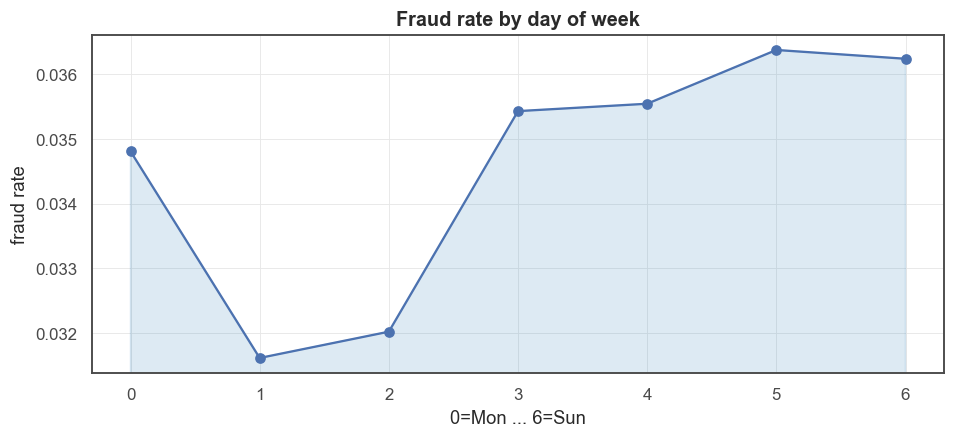

In [84]:
rate = df_s.groupby("dow")["isFraud"].mean()
ax = rate.plot(marker = "o", figsize = (10,4), title = "Fraud rate by day of week")
ylim = ax.get_ylim()  #remember the tight auto-scaled range before adding the fill
ax.fill_between(rate.index, rate.values, color="#1f77b4", alpha=0.15)
ax.set_ylim(ylim)  #restore it so the shaded area doesn't pull the axis down to 0
ax.set_ylabel("fraud rate"); ax.set_xlabel("0=Mon ... 6=Sun"); plt.show()

The plot above summarizes mean fraud share by weekday: rates are highest at the start of the week and lowest mid-week, then rise again toward the weekend; the effect is modest but consistent and supports including calendar features (or at least checking stability by weekday in later validation).

#### Fraud rate by hour of day

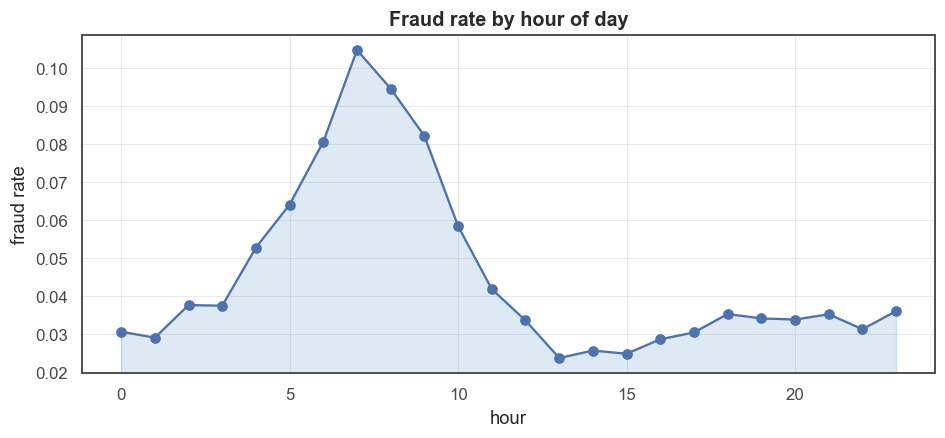

In [85]:
rate = df_s.groupby("hour")["isFraud"].mean()
ax = rate.plot(marker = "o", figsize = (10,4), title = "Fraud rate by hour of day")
ylim = ax.get_ylim()  #remember the tight auto-scaled range before adding the fill
ax.fill_between(rate.index, rate.values, color="#1f77b4", alpha=0.15)
ax.set_ylim(ylim)  #restore it so the shaded area doesn't pull the axis down to 0
ax.set_ylabel("fraud rate"); plt.show()

The plot above shows the average fraud share across 24 hours computed on a sample for speed: fraud peaks in the early morning window (~6-9), then drops and stays comparatively low through the afternoon and evening; the strong morning spike suggests a time-of-day pattern that could help with time-aware evaluation or thresholding.

#### Weekly fraud rate

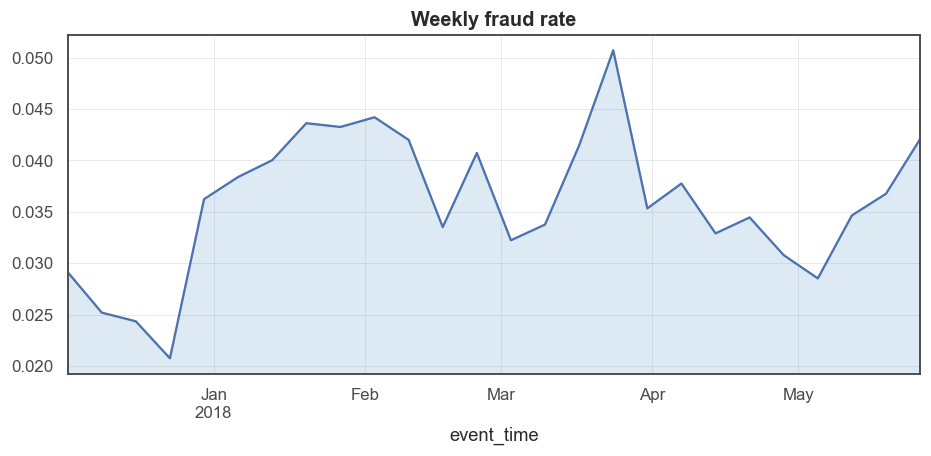

In [86]:
weekly = train.set_index("event_time")["isFraud"].resample("7D").mean()
ax = weekly.plot(title = "Weekly fraud rate")
ylim = ax.get_ylim()  #remember the tight auto-scaled range before adding the fill
ax.fill_between(weekly.index, weekly.values, color="#1f77b4", alpha=0.15)
ax.set_ylim(ylim)  #restore it so the shaded area doesn't pull the axis down to 0
plt.show()

The plot above with weekly resampling shows that the fraud rate is not constant over time: there are waves with local highs and lows and a notable surge around late April/early May. This motivates strictly chronological splits and monitoring of drift when comparing models.

#### Daily volume and fraud counts
Resamples the data into daily buckets, then counts total transactions and sums isFraud to get daily fraud counts

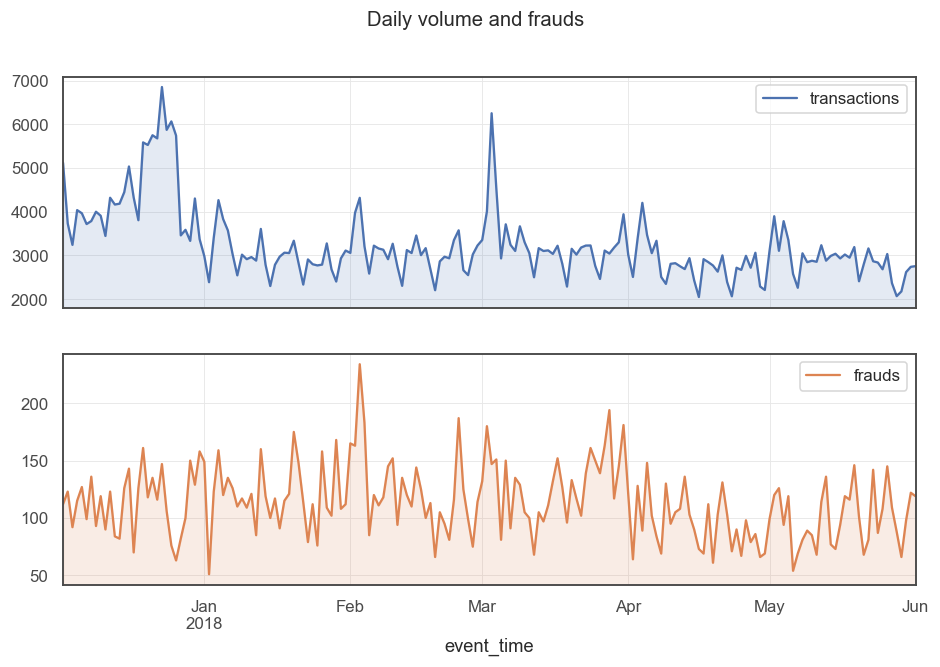

In [87]:
#daily volume+fraud count timeline 
daily = train.set_index("event_time").resample("1D")["isFraud"].agg(["count","sum"])
daily.rename(columns = {"count":"transactions","sum":"frauds"}, inplace = True)
axes = daily.plot(subplots = True, figsize = (10,6), title = "Daily volume and frauds")

for ax, col in zip(axes, daily.columns):
    line_color = ax.lines[0].get_color()  #match the fill to each subplot's own line color
    ylim = ax.get_ylim()  #remember the tight auto-scaled range before adding the fill
    ax.fill_between(daily.index, daily[col], color=line_color, alpha=0.15)
    ax.set_ylim(ylim)  #restore it so the shaded area doesn't pull the axis down to 0

plt.show()

The top panel shows total transactions per day; The bottom panel shows the number of frauds per day.
  
Volume varies from day to day, and fraud counts fluctuate independently rather than simply tracking volume. This confirms that precision/recall at a fixed alert budget is more meaningful than ROC-AUC alone, and it reinforces the need to report results over time windows, not just one aggregate score.

#### Hour × Day of week fraud heatmap
with average fraud rate by hour of day (x-axis) and day of week (y-axis), computed on a 200k sample.

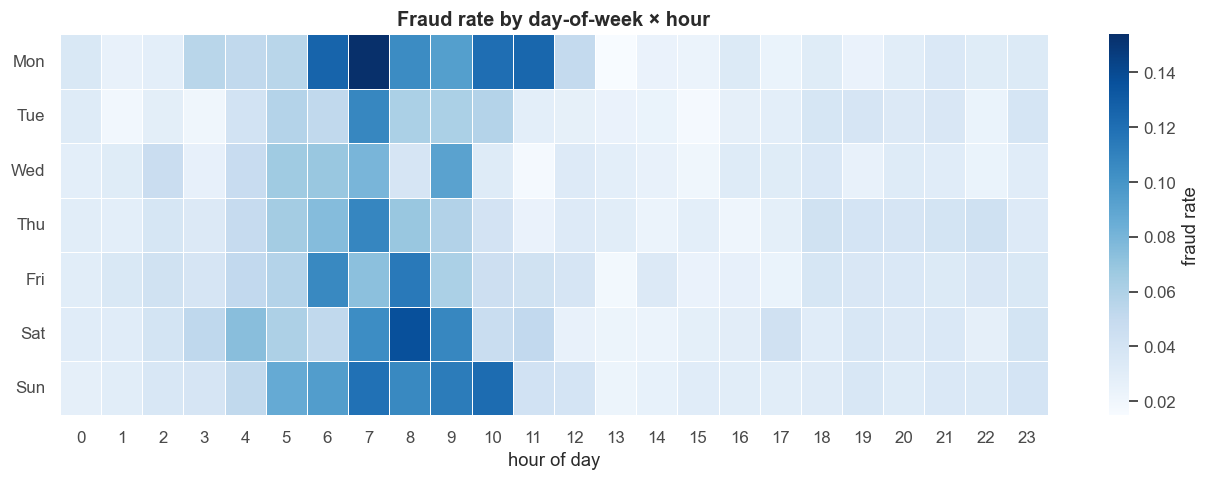

In [88]:
df_s = train.sample(200_000, random_state=0) if len(train) > 200_000 else train.copy()
df_s["hour"] = df_s["event_time"].dt.hour
df_s["dow"]  = df_s["event_time"].dt.dayofweek

#reshapes the sample into a day-of-week by hour grid, where each cell is the average fraud rate for that day/hour combination
pivot = df_s.pivot_table(index="dow", columns="hour", values="isFraud", aggfunc="mean")

#maps the numeric day codes to real day names, since "dow" is only readable as a number otherwise
dow_labels = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]

plt.figure(figsize=(12,4.5))
#single-hue blue colormap 
ax = sns.heatmap(pivot, cmap="Blues", linewidths=0.5, linecolor="white",
                  cbar_kws={"label": "fraud rate"})
ax.set_yticklabels(dow_labels, rotation=0) #swap y-axis labels for the day names

plt.title("Fraud rate by day-of-week \u00d7 hour")
plt.xlabel("hour of day"); plt.ylabel("")
plt.tight_layout(); plt.show()

It results in clear hot band in early morning hours, especially mid-week, with lower rates late evening/night. These time patterns can guide time-aware features; the values are small because of class imbalance; sampling + missing timezone info can blur exact peaks.

#### Time profiles: rolling fraud rate & volume

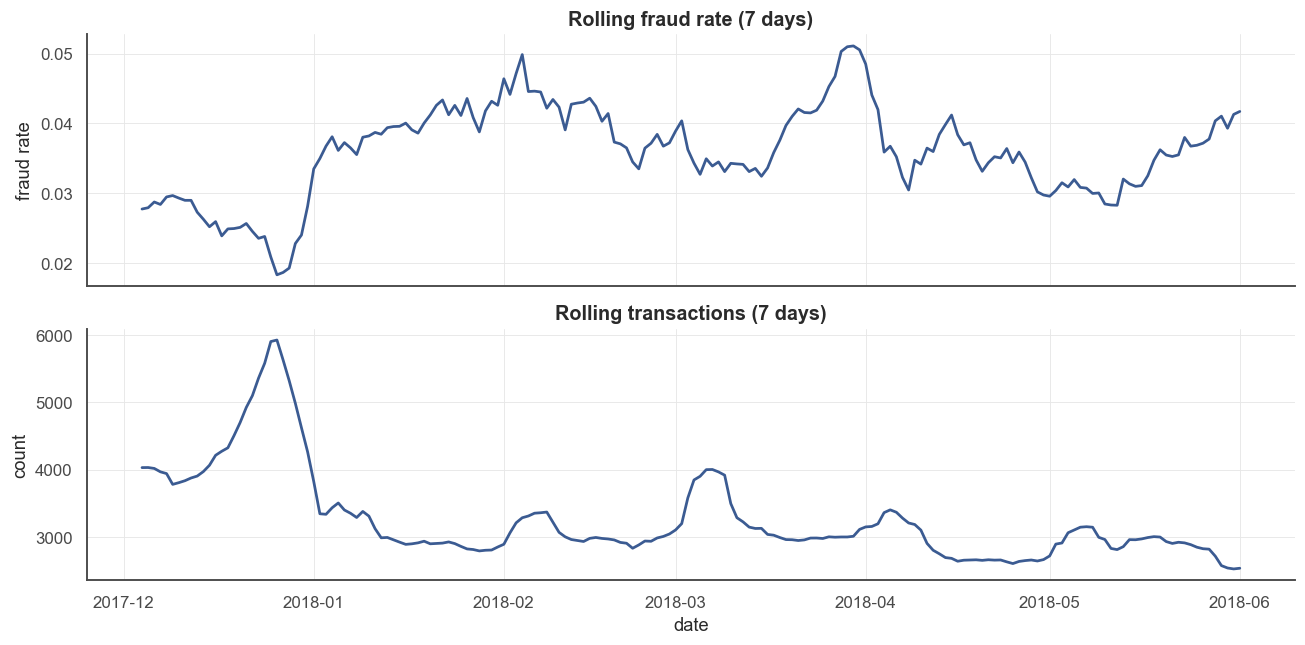

In [89]:
#7 day window
tmp = (train.assign(day = train["event_time"].dt.to_period("D").astype(str))
             .groupby("day")
             .agg(txn = ("TransactionID","count"),
                  fr = ("isFraud","mean"))
             .reset_index())

tmp["day"] = pd.to_datetime(tmp["day"])
tmp = tmp.sort_values("day")
#smooths the daily fraud rate with a 7-day rolling average so day to day noise does not hide the overall trend
tmp["fr_roll7"] = tmp["fr"].rolling(7, min_periods = 3).mean()
tmp["txn_roll7"] = tmp["txn"].rolling(7, min_periods = 3).mean()

fig, ax = plt.subplots(2,1, figsize = (12,6), sharex = True)
ax[0].plot(tmp["day"], tmp["fr_roll7"], color=ACCENT, linewidth=1.8)
ax[0].set_title("Rolling fraud rate (7 days)")
ax[0].set_ylabel("fraud rate")
ax[1].plot(tmp["day"], tmp["txn_roll7"], color=ACCENT, linewidth=1.8)
ax[1].set_title("Rolling transactions (7 days)")
ax[1].set_ylabel("count"); ax[1].set_xlabel("date")
sns.despine()
plt.tight_layout(); plt.show()

Above are the 7-days moving fraud rate, that shows clear time variation relative to transaction volume, which supports using chronological validation and motivates checking model stability and drift over time.

#### Missingness Overview (top offenders)
With features being ranked by missing-value share in descending order.

In [90]:
m = train.isna().mean().sort_values(ascending = False).to_frame("missing_share")
display(m.head(20))

,missing_share
id_24,0.991962
id_25,0.991310
id_08,0.991271
id_07,0.991271
id_21,0.991264
id_26,0.991257
id_23,0.991247
id_22,0.991247
id_27,0.991247
dist2,0.936284


Several `id_*` columns (eg. `id_24`, `id_25`, `id_08`) are missing in about 99% of rows, and some `D*`/`dist*` fields are also heavily missing (around 87-94%).

This indicates a very sparse identity/behavior block, and basically tells that missingness itself carries signal here.

So in preprocessing it will be better to keep explicit missing value flags for these columns, impute the rest with the train-window median, and drop anything still >98% missing since it is unlikely to add anything stable.

#### Missingness Heatmap (top 60 by missing share)
Shows where the columns are sorted by share of NaNs, making it easy to see which features are missing across many transactions at once

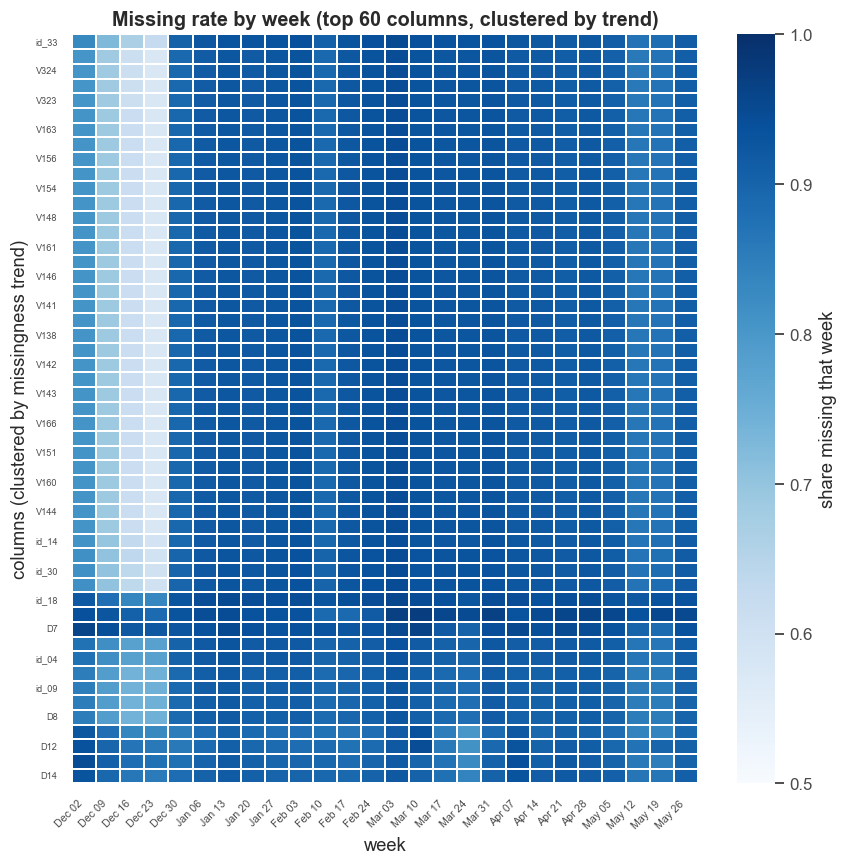

In [91]:
from matplotlib.colors import ListedColormap
from scipy.cluster.hierarchy import linkage, leaves_list
m = train.isna().mean().sort_values(ascending=False)
top = m.head(60).index

#missing rate per column, resampled weekly, same 7D binning as the weekly fraud-rate chart above
weekly_missing = (
    train.set_index("event_time")[top]
    .isna()
    .astype(int)
    .resample("7D")
    .mean()
    .T
)

row_range = weekly_missing.max(axis=1) - weekly_missing.min(axis=1)
weekly_missing = weekly_missing[row_range > 0.05]

#cluster remaining columns by how similarly their missing rate moves over time
col_order = leaves_list(linkage(weekly_missing, method='average', metric='euclidean'))
weekly_missing = weekly_missing.iloc[col_order]

plt.figure(figsize=(8, 8))
ax = sns.heatmap(weekly_missing, cmap='Blues', vmin=0.5, vmax=1,
                  linewidths=0.3, linecolor='white',
                  cbar_kws={'label': 'share missing that week'})
plt.title("Missing rate by week (top 60 columns, clustered by trend)")
plt.xlabel("week")
plt.ylabel("columns (clustered by missingness trend)")
plt.yticks(fontsize=6)
xticklabels = [d.strftime('%b %d') for d in weekly_missing.columns]
ax.set_xticklabels(xticklabels, rotation=45, ha='right', fontsize=7)
plt.tight_layout()
plt.show()

Many `id_*`, `dist2`, and some `D*`/`V* `features have >85-99% missing.

High missing columns may still carry signal, but they need explicit missing indicators.
Some features might be dropped later if they add noise.

#### Identity coverage by key columns
non-missing share and number of unique values per column. 

In [92]:
#collects all the id columns plus the device/email columns, since these are the identity-related fields being profiled here
id_cols = [c for c in train.columns if c.startswith("id_")] + ["DeviceType","DeviceInfo","P_emaildomain","R_emaildomain"]
id_cols = [c for c in id_cols if c in train.columns]
rows = []
for c in id_cols:
    s = train[c]
    rows.append({
        "col": c,
        "non_missing_share": (1 - s.isna().mean()), #is the share of rows that actually have a value for this column, so higher means better coverage
        "n_unique": s.nunique(dropna = True)
    })
pd.DataFrame(rows).sort_values(["non_missing_share","n_unique"], ascending = [False, False]).head(20)

,col,non_missing_share,n_unique
40,P_emaildomain,0.840051,59
0,id_01,0.244239,77
11,id_12,0.244239,2
14,id_15,0.238739,3
34,id_35,0.238739,2
35,id_36,0.238739,2
36,id_37,0.238739,2
37,id_38,0.238739,2
10,id_11,0.238727,365
27,id_28,0.238727,2


- high-coverage/moderate-cardinality fields (e.g., `P_emaildomain`) are good for normal encoding; 
- low-coverage few-level `IDs` act like flags; 
- very high-cardinality with low coverage may need frequency encoding or pruning.

## Descriptive feature behavior

#### Numeric histograms by labels
histograms for non-fraud vs. fraud, with a set of numeric-ish columns (`TransactionAmt`, `card1–card5`, `addr1`, `addr2`).

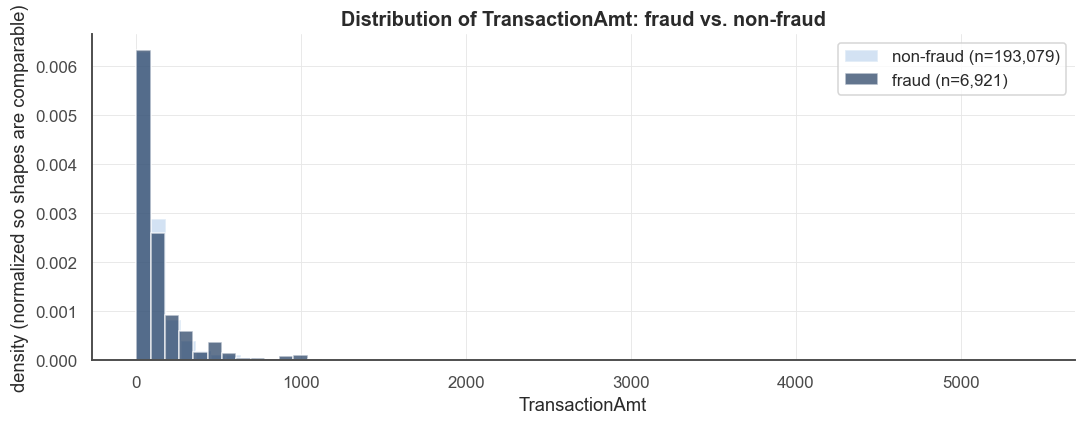

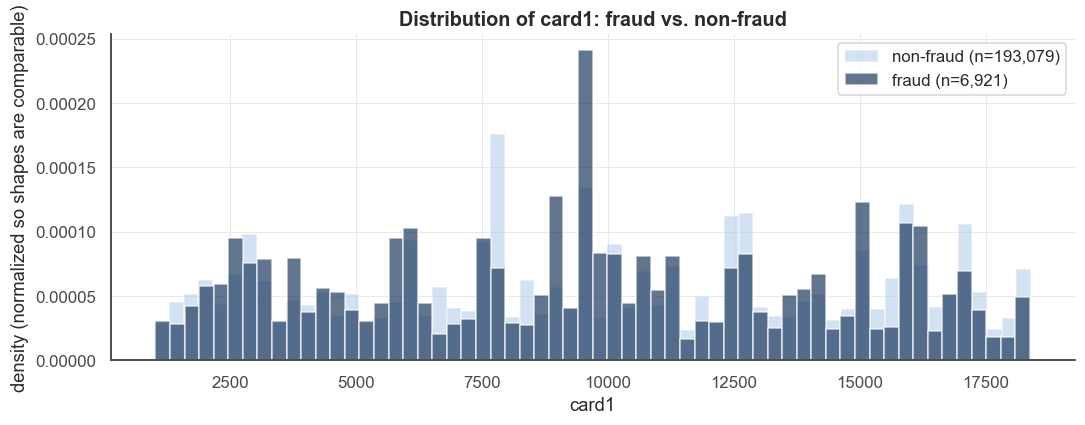

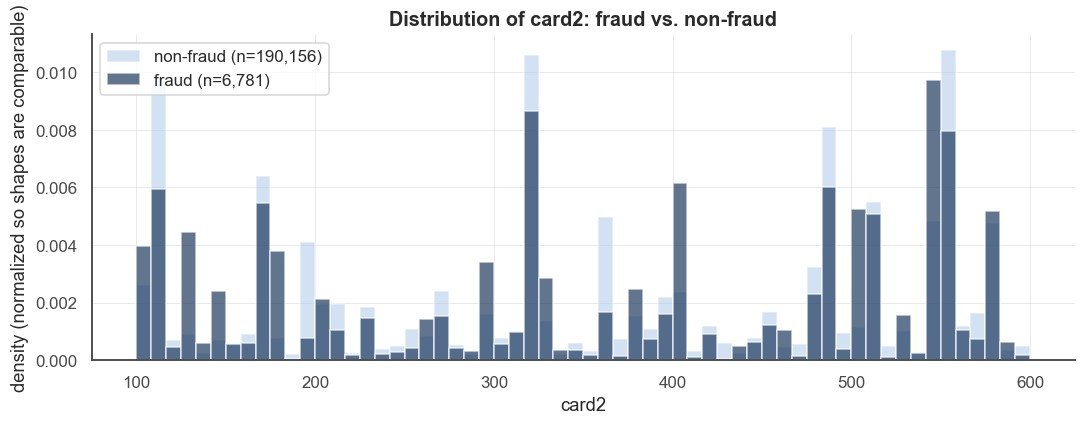

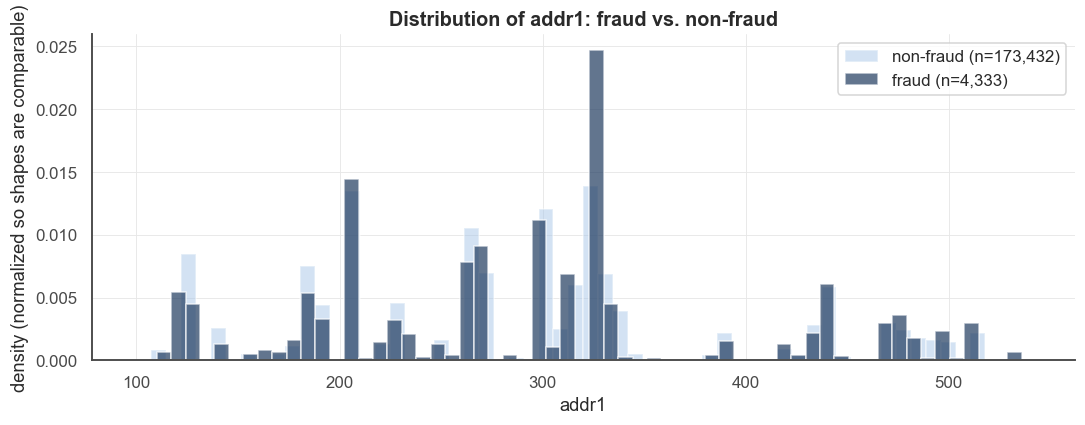

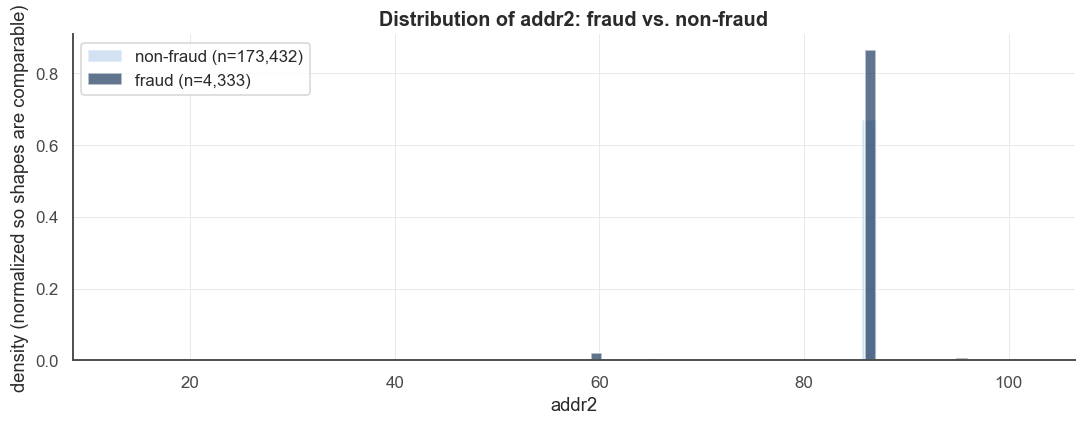

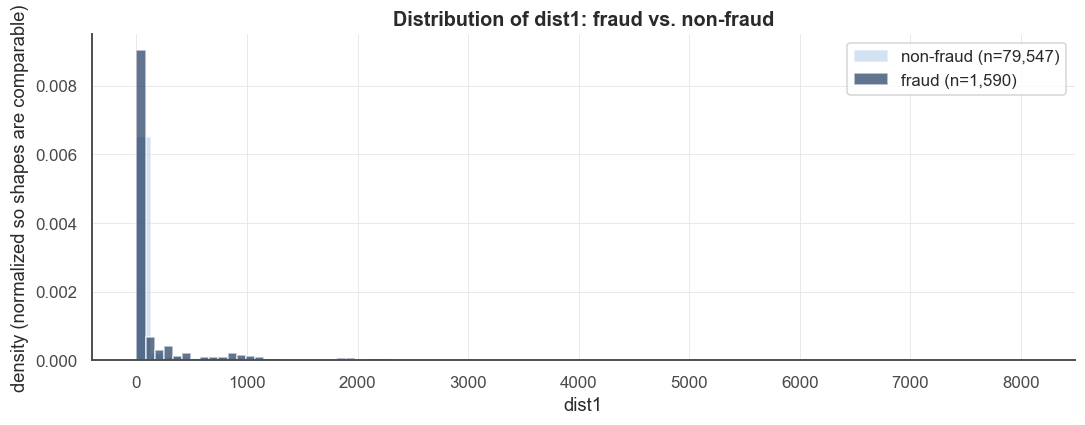

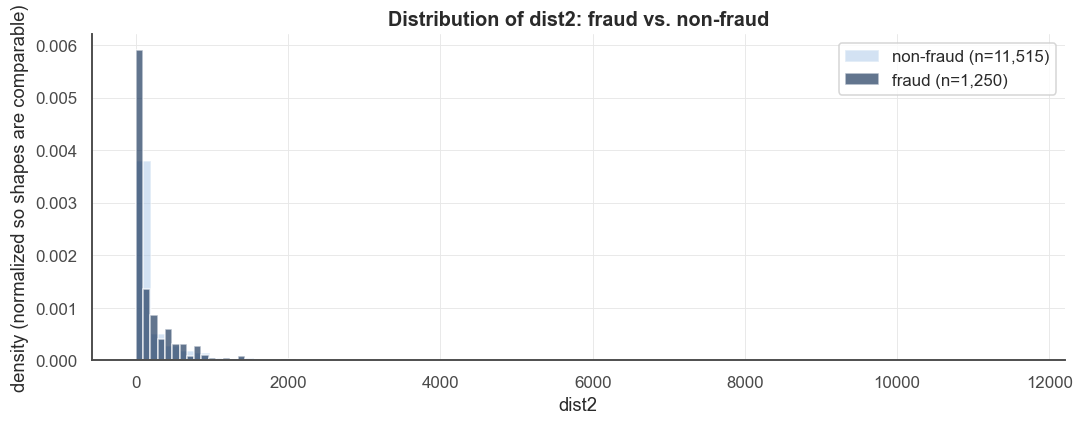

In [93]:
#only keep the columns from this list that actually exist in the sampled dataframe
numeric_cols = [c for c in ["TransactionAmt","card1","card2","addr1","addr2","dist1","dist2"] if c in df_s.columns]

for col in numeric_cols:
    vals_0 = df_s.loc[df_s.isFraud==0, col].dropna()
    vals_1 = df_s.loc[df_s.isFraud==1, col].dropna()

    fig, ax = plt.subplots(figsize=(10,4))
    #density=True normalizes each histogram to its own area, so shapes are comparable even though
    #fraud has far fewer rows than non-fraud, overlaying avoids the shared-axis problem
    #squashing the fraud panel down to a flat line
    ax.hist(vals_0, bins=60, density=True, alpha=0.5, color="#A9C6E8", label=f"non-fraud (n={len(vals_0):,})")
    ax.hist(vals_1, bins=60, density=True, alpha=0.7, color=ACCENT_DARK, label=f"fraud (n={len(vals_1):,})")
    ax.set_title(f"Distribution of {col}: fraud vs. non-fraud")
    ax.set_xlabel(col)
    ax.set_ylabel("density (normalized so shapes are comparable)")
    ax.legend()
    sns.despine()
    plt.tight_layout()
    plt.show()

- TransactionAmt has a heavy right tail; fraud may cluster at certain ranges.

- Card/address features often show clustered modes; fraud distributions can be more concentrated/sparse, hinting at informative ranges.

These heavy tailed distributions matter for later modeling, where will be good to standardize them before feeding Isolation Forest and the Autoencoder, since those models are distance/reconstruction-based and sensitive to raw scale.

#### Per-column description of "TransactionAmt"
summarry for `TransactionAmt` over the entire joined train set. 

In [94]:
col = "TransactionAmt" 
desc = train[col].describe().to_frame("all")
desc.loc["n_unique"] = train[col].nunique(dropna = True)
desc.loc["NaNs"] = train[col].isna().sum()
desc.loc["NaN_share"] = train[col].isna().mean().round(4)
desc

,all
count,590540.000000
mean,135.027176
std,239.162522
min,0.251000
25%,43.321000
50%,68.769000
75%,125.000000
max,31937.391000
n_unique,20902.000000
NaNs,0.000000


- `mean` ≈ 135 and a much larger `std` (≈ 239) tell us the distribution is right-skewed with a long tail;
- `min` (≈ 0.25) and `max` (≈ 31,937) show very wide range;
- `medians` and `quartiles` (≈ 43 → 69 → 125) reinforce the heavy-tailed shape. `n_unique` (~20.9k) indicates high cardinality;
- `NaNs` and `NaN_share` are 0 here, so `TransactionAmt` has no missing values in the joined training table.

#### Transaction amount overview (raw + log view + fraud rate by decile)

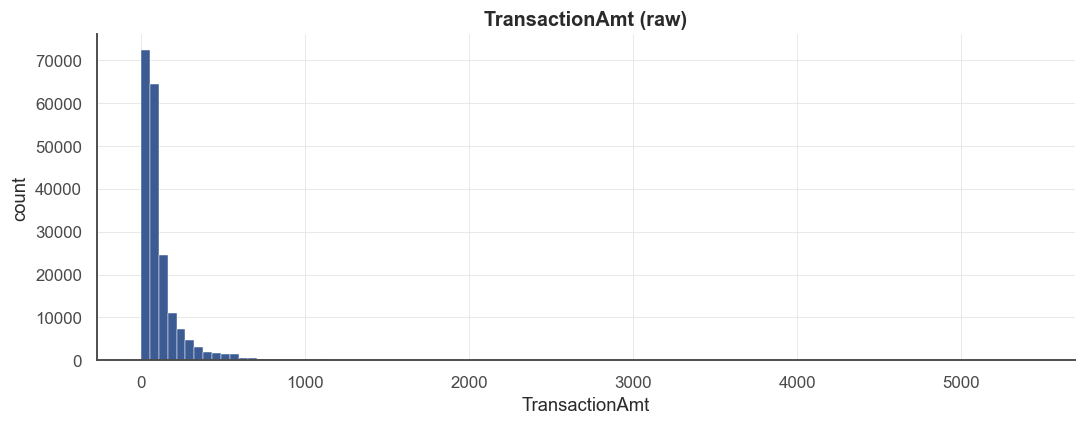

In [95]:
#raw hist (non-log)
col = "TransactionAmt"
fig, ax = plt.subplots(figsize=(10,4))
df_s[col].dropna().hist(bins=100, ax=ax, color=ACCENT, edgecolor="white", linewidth=0.3)
ax.set_title("TransactionAmt (raw)")
ax.set_xlabel(col); ax.set_ylabel("count")
sns.despine()
plt.tight_layout(); plt.show()

Above is the original distribution of `TransactionAmt` without any transformations. It is extremely right-skewed with a long tail, so most purchases are small, and a few are very large. This alerts that models using raw amounts may be dominated by the tail and that scale-sensitive methods (e.g., distance-based) will benefit from a transform or scaling.

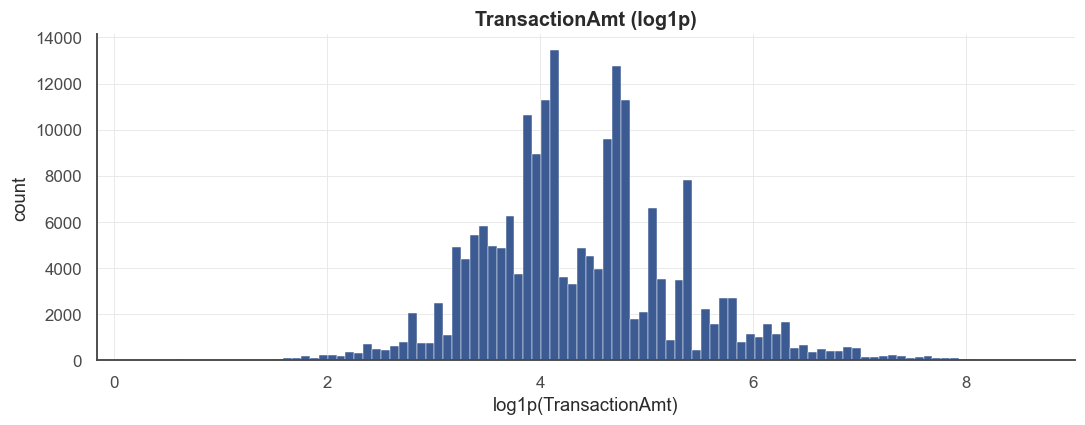

In [96]:
#log1p hist (handles zeros)
col = "TransactionAmt"
fig, ax = plt.subplots(figsize=(10,4))
np.log1p(df_s[col].dropna()).hist(bins=100, ax=ax, color=ACCENT, edgecolor="white", linewidth=0.3)
ax.set_title("TransactionAmt (log1p)")
ax.set_xlabel("log1p(TransactionAmt)"); ax.set_ylabel("count")
sns.despine()
plt.tight_layout(); plt.show()

The histogram above shows that after applying `log1p`(`TransactionAmt`), the distribution becomes much closer to unimodal and symmetric, and handles zeros safely. TransactionAmt stays heavily skewed in its raw form, which is worth keeping in mind when deciding how to handle this feature in preprocessing.

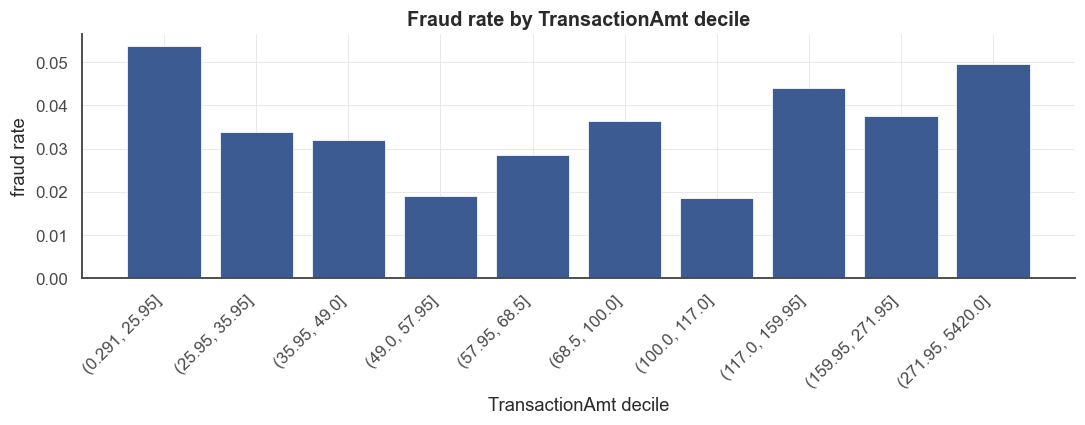

In [97]:
#fraud rate by decile
col = "TransactionAmt"
#splits TransactionAmt into 10 equal sized groups to see how fraud rate changes across the amount range
bins = pd.qcut(df_s[col].fillna(df_s[col].median()), 10, duplicates="drop")
tmp = df_s.groupby(bins)["isFraud"].mean().reset_index()

fig, ax = plt.subplots(figsize=(10,4))
ax.bar(tmp[col].astype(str), tmp["isFraud"], color=ACCENT, edgecolor="white", linewidth=0.5)
ax.set_xticklabels(tmp[col].astype(str), rotation=45, ha="right")
ax.set_title("Fraud rate by TransactionAmt decile")
ax.set_ylabel("fraud rate"); ax.set_xlabel("TransactionAmt decile")
sns.despine()
plt.tight_layout(); plt.show()

Above is a split of `TransactionAmt` into 10 equal-frequency bins and a computed mean of isFraud in each bin.

The bar chart above shows that fraud rate is not flat across deciles, so mid-high and very high amounts show elevated fraud compared to the lowest bins. This is actionable for baselines (simple thresholding) and motivates including a calibrated, possibly non-linear effect of amount in any supervised baseline and as a strong signal for unsupervised scoring.

#### Amount vs. fraud (binned/log)

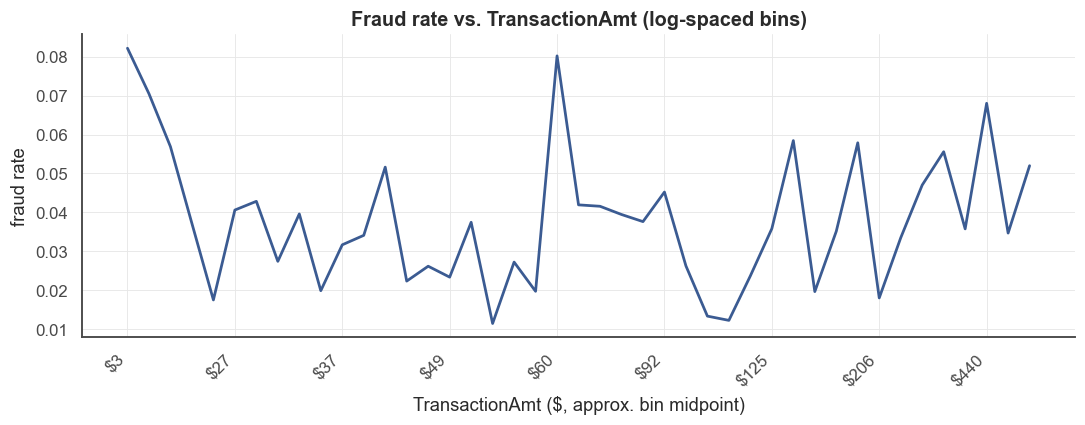

In [98]:
#Log1p for stability
z = df_s[["isFraud","TransactionAmt"]].dropna().copy()
z["logAmt"] = np.log1p(z["TransactionAmt"])
#uses more bins on the log-transformed amount to check the fraud-rate pattern holds at a finer resolution
bins = pd.qcut(z["logAmt"], 50, duplicates="drop")
curve = z.groupby(bins)["isFraud"].mean()

#convert each bin back to its midpoint dollar amount, so the x-axis is readable in real units
bin_mid_amt = [np.expm1(interval.mid) for interval in curve.index]

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(range(len(curve)), curve.values, color=ACCENT, linewidth=1.8)
ax.set_title("Fraud rate vs. TransactionAmt (log-spaced bins)")
ax.set_ylabel("fraud rate"); ax.set_xlabel("TransactionAmt ($, approx. bin midpoint)")

#only label every 5th tick so the amounts stay readable instead of overlapping
tick_idx = range(0, len(curve), 5)
ax.set_xticks(tick_idx)
ax.set_xticklabels([f"${bin_mid_amt[i]:,.0f}" for i in tick_idx], rotation=45, ha="right")

sns.despine()
plt.tight_layout(); plt.show()

Above is a plot of `TransactionAmt` transformed with `log1p`, split into 50 quantile bins; the line shows mean fraud rate per bin. The lowest amounts have elevated fraud, the middle range dips, and the upper bins trend up again (noisy at extremes due to low counts).

It matters, because the confirmed amount is predictive. It motivates features like `logAmt`, non-linear transforms, or target-encoded deciles.

The spikes at the right may come from sparse bins. We can try to reduce noise by using fewer bins (e.g., 20), adding a rolling mean, or plotting with bin counts alongside.

#### Identity/device/browser descriptive profile

In [99]:
def top_profile(df, col, target = "isFraud", top_n = 15, min_count = 200):
    if col not in df.columns:
        print(f"[skip] {col} not found")
        return
    tmp = df[[col, target]].copy()
    tmp[col] = tmp[col].fillna("__MISSING__").astype(str)
    #for each category value, counts how many rows there are and what share of them are fraud
    g = (tmp.groupby(col)[target]
           .agg(count = "size", fraud_rate = "mean")
           .sort_values("count", ascending = False))
    #only keeps categories with enough rows to be meaningful, then keeps the most frequent ones
    g = g[g["count"] >= min_count].head(top_n)
    print(f"\n=== {col} (top {top_n}, count>={min_count}) ===")
    display(g)

for c in ["DeviceType", "DeviceInfo", "id_30", "id_31", "P_emaildomain", "R_emaildomain"]:
    top_profile(train, c)


=== DeviceType (top 15, count>=200) ===


,count,fraud_rate
DeviceType,,
__MISSING__,449730,0.021017
desktop,85165,0.065215
mobile,55645,0.101662



=== DeviceInfo (top 15, count>=200) ===


,count,fraud_rate
DeviceInfo,,
__MISSING__,471874,0.025549
Windows,47722,0.065400
iOS Device,19782,0.062683
MacOS,12573,0.022111
Trident/7.0,7440,0.012903
rv:11.0,1901,0.039979
rv:57.0,962,0.107069
SM-J700M Build/MMB29K,549,0.109290
SM-G610M Build/MMB29K,461,0.080260



=== id_30 (top 15, count>=200) ===


...

,count,fraud_rate
id_31,,
__MISSING__,450258,0.021081
chrome 63.0,22000,0.068318
mobile safari 11.0,13423,0.062728
mobile safari generic,11474,0.099878
ie 11.0 for desktop,9030,0.019380
safari generic,8195,0.025015
chrome 62.0,7182,0.041632
chrome 65.0,6871,0.098821
chrome 64.0,6711,0.091641



=== P_emaildomain (top 15, count>=200) ===


,count,fraud_rate
P_emaildomain,,
gmail.com,228355,0.043542
yahoo.com,100934,0.022757
__MISSING__,94456,0.029538
hotmail.com,45250,0.052950
anonymous.com,36998,0.023217
aol.com,28289,0.021811
comcast.net,7888,0.031187
icloud.com,6267,0.031434
outlook.com,5096,0.094584



=== R_emaildomain (top 15, count>=200) ===


,count,fraud_rate
R_emaildomain,,
__MISSING__,453249,0.020819
gmail.com,57147,0.119184
hotmail.com,27509,0.077793
anonymous.com,20529,0.029130
yahoo.com,11842,0.051512
aol.com,3701,0.034855
outlook.com,2507,0.165138
comcast.net,1812,0.011589
yahoo.com.mx,1508,0.010610


The tables above summarize the most frequent categories with at least 200 rows, for `DeviceType`, `DeviceInfo`, `id_30` (OS), `id_31` (browser), `P_emaildomain`, and `R_emaildomain`, showing both volume (count) and fraud prevalence (fraud_rate).

The missingness there is very large in identity/browser fields, so identity coverage is sparse.

Fraud rates differ noticeably across device and browser categories, for example, mobile-related/browser-generic groups tend to have higher rates than several desktop/legacy groups.

Email domains also show heterogeneous risk, since some common domains are near baseline, while a few categories have clearly elevated fraud rates.

`R_emaildomain` appears much sparser than `P_emaildomain`, but certain sender/receiver domain categories still show strong fraud-rate differences.

This part needs to be observed, because Device/browser/email features are geneally informative, missingness should be treated as meaningful signal, and not silently dropped, domain normalization and rare-category grouping are important next steps before modeling.

#### Key categorical features (top categories)
Comparison of fraud rates across the most frequent categories of product/card/email/device/identity features.

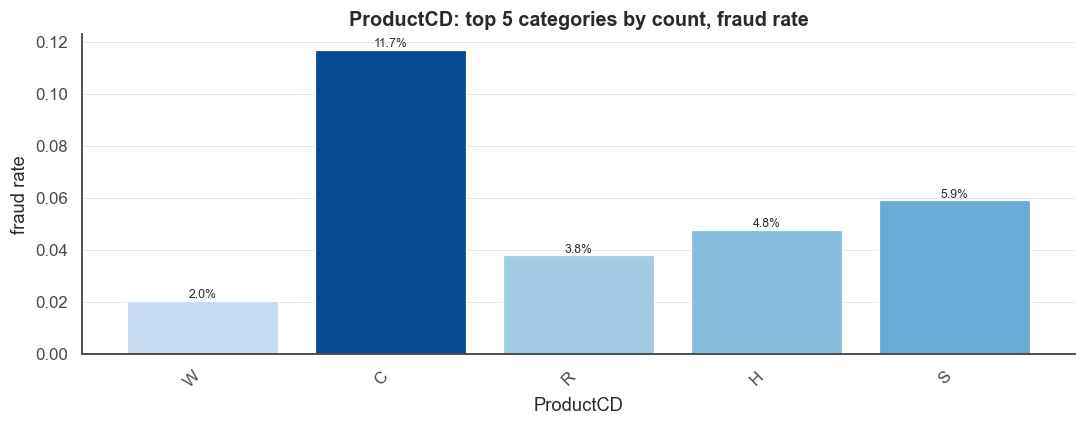

,ProductCD,count,fraud_rate
0,W,439670,0.020399
1,C,68519,0.116873
2,R,37699,0.037826
3,H,33024,0.047662
4,S,11628,0.058996


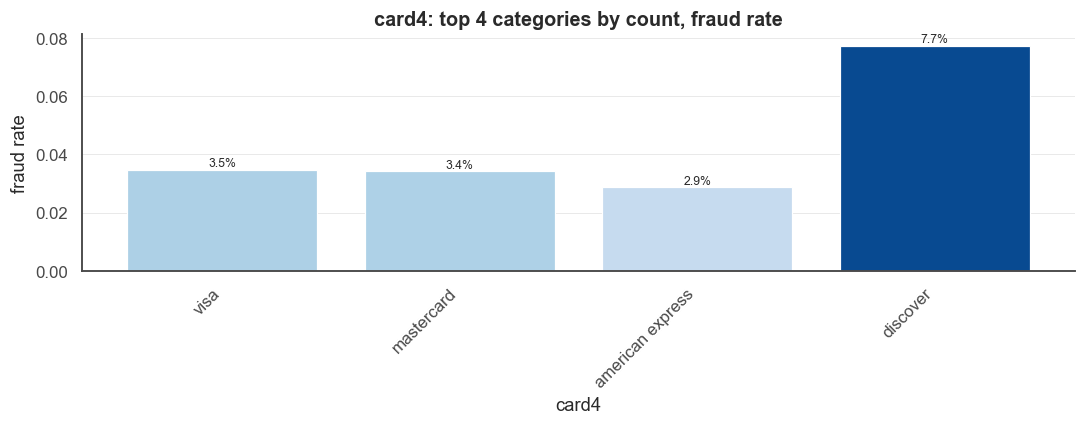

,card4,count,fraud_rate
0,visa,384767,0.034756
1,mastercard,189217,0.034331
2,american express,8328,0.028698
3,discover,6651,0.077282


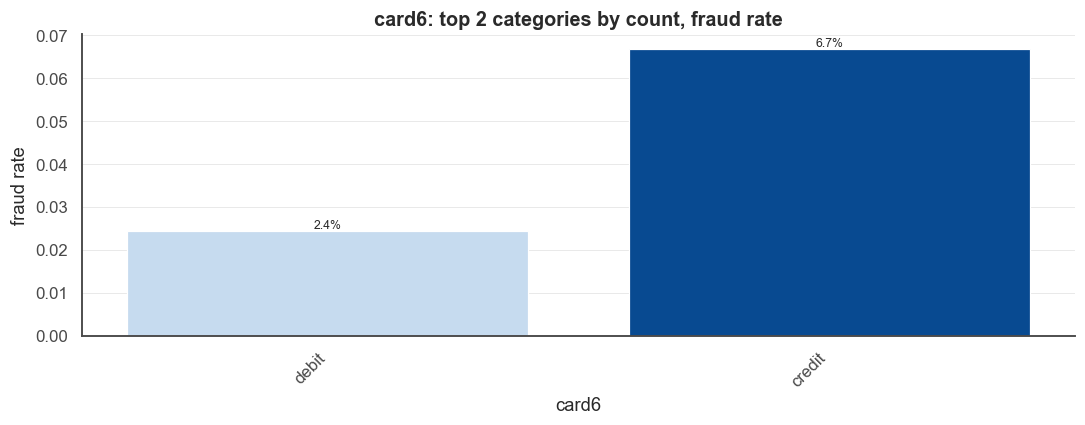

,card6,count,fraud_rate
0,debit,439938,0.024263
1,credit,148986,0.066785


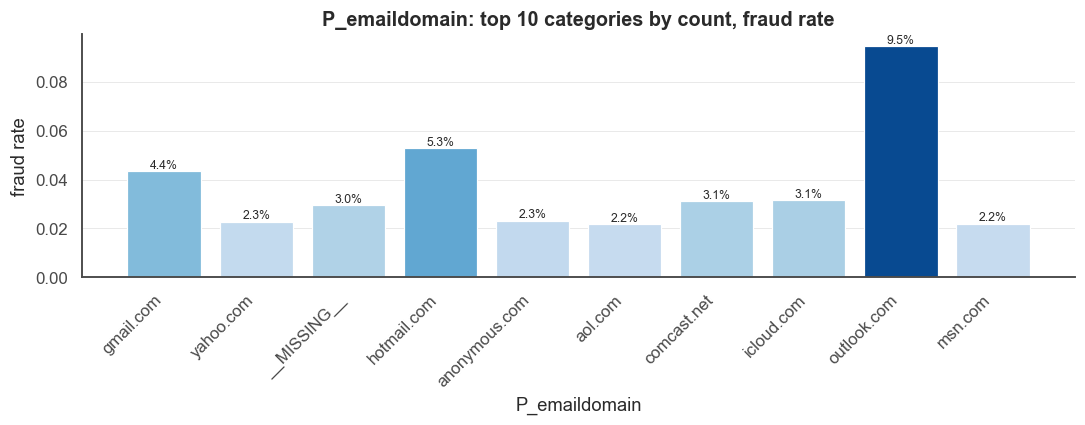

,P_emaildomain,count,fraud_rate
0,gmail.com,228355,0.043542
1,yahoo.com,100934,0.022757
2,__MISSING__,94456,0.029538
3,hotmail.com,45250,0.052950
4,anonymous.com,36998,0.023217
5,aol.com,28289,0.021811
6,comcast.net,7888,0.031187
7,icloud.com,6267,0.031434
8,outlook.com,5096,0.094584
9,msn.com,4092,0.021994


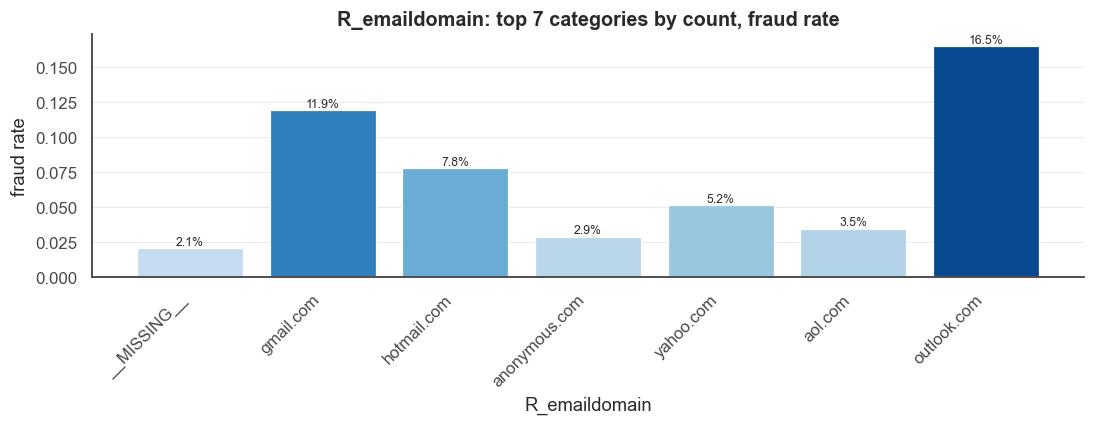

,R_emaildomain,count,fraud_rate
0,__MISSING__,453249,0.020819
1,gmail.com,57147,0.119184
2,hotmail.com,27509,0.077793
3,anonymous.com,20529,0.029130
4,yahoo.com,11842,0.051512
5,aol.com,3701,0.034855
6,outlook.com,2507,0.165138


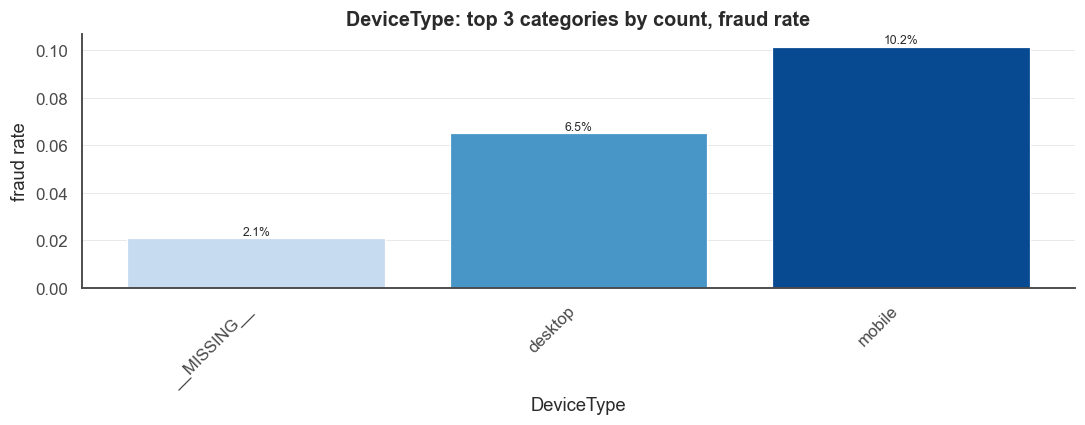

,DeviceType,count,fraud_rate
0,__MISSING__,449730,0.021017
1,desktop,85165,0.065215
2,mobile,55645,0.101662


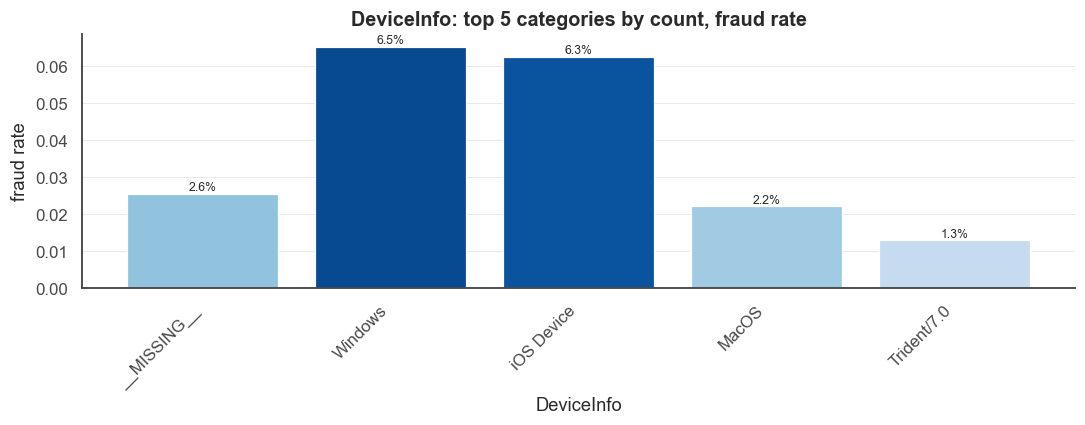

,DeviceInfo,count,fraud_rate
0,__MISSING__,471874,0.025549
1,Windows,47722,0.065400
2,iOS Device,19782,0.062683
3,MacOS,12573,0.022111
4,Trident/7.0,7440,0.012903


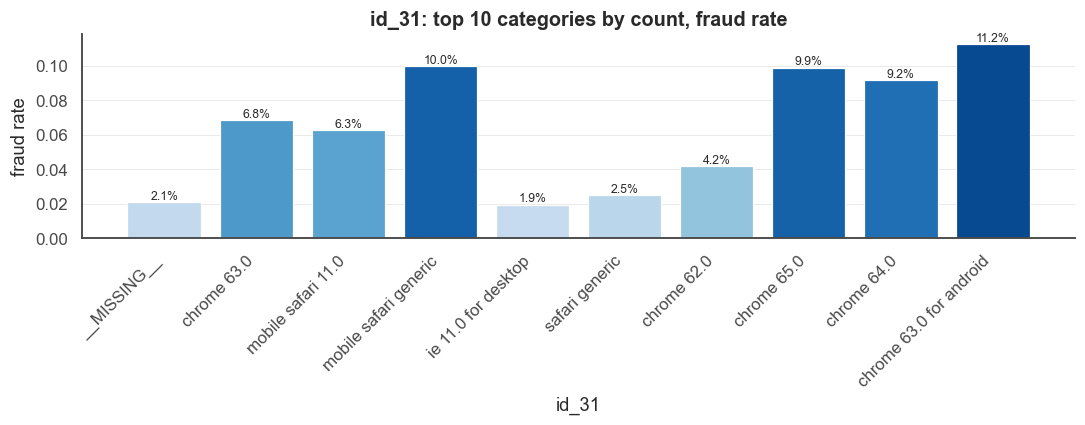

,id_31,count,fraud_rate
0,__MISSING__,450258,0.021081
1,chrome 63.0,22000,0.068318
2,mobile safari 11.0,13423,0.062728
3,mobile safari generic,11474,0.099878
4,ie 11.0 for desktop,9030,0.019380
5,safari generic,8195,0.025015
6,chrome 62.0,7182,0.041632
7,chrome 65.0,6871,0.098821
8,chrome 64.0,6711,0.091641
9,chrome 63.0 for android,5806,0.112470


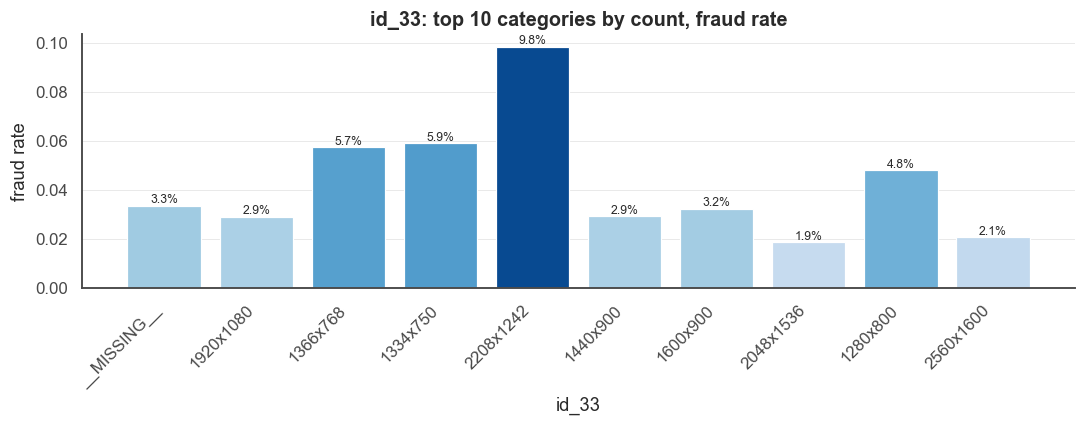

,id_33,count,fraud_rate
0,__MISSING__,517251,0.033446
1,1920x1080,16874,0.029039
2,1366x768,8605,0.057292
3,1334x750,6447,0.059097
4,2208x1242,4900,0.098367
5,1440x900,4384,0.029197
6,1600x900,3510,0.032194
7,2048x1536,3482,0.018667
8,1280x800,2149,0.047929
9,2560x1600,2093,0.020545


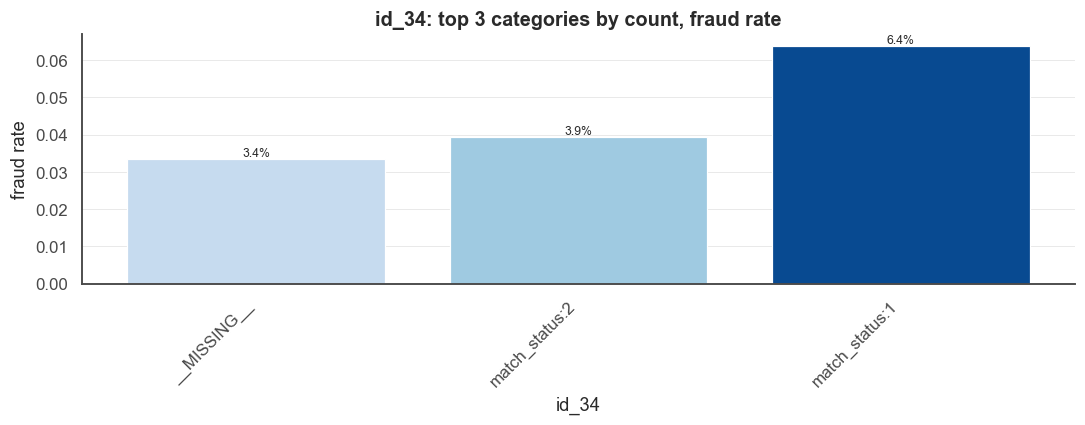

,id_34,count,fraud_rate
0,__MISSING__,512735,0.033503
1,match_status:2,60011,0.039293
2,match_status:1,17376,0.063651


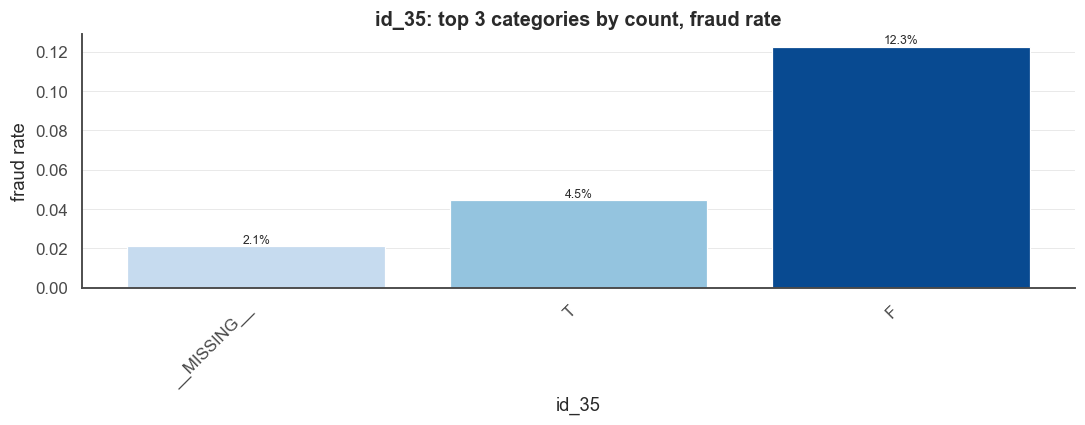

,id_35,count,fraud_rate
0,__MISSING__,449555,0.021001
1,T,77814,0.044683
2,F,63171,0.122604


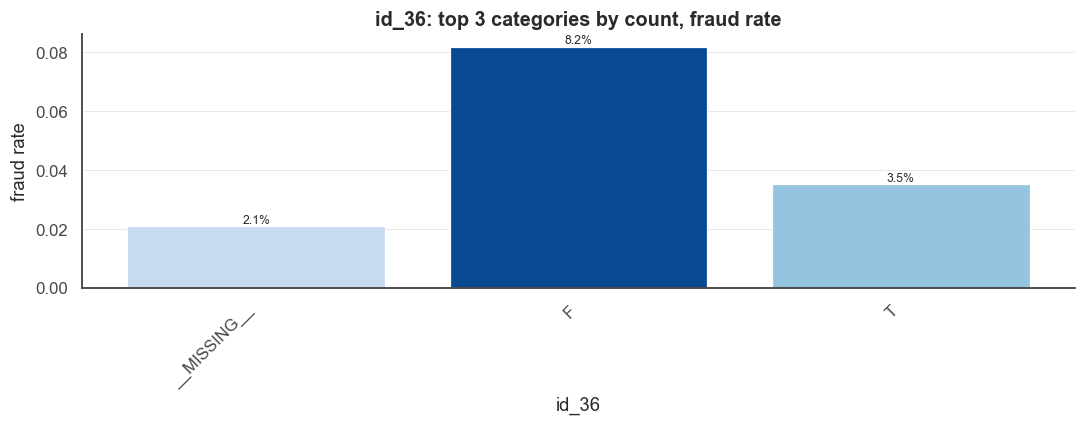

,id_36,count,fraud_rate
0,__MISSING__,449555,0.021001
1,F,134066,0.081885
2,T,6919,0.035265


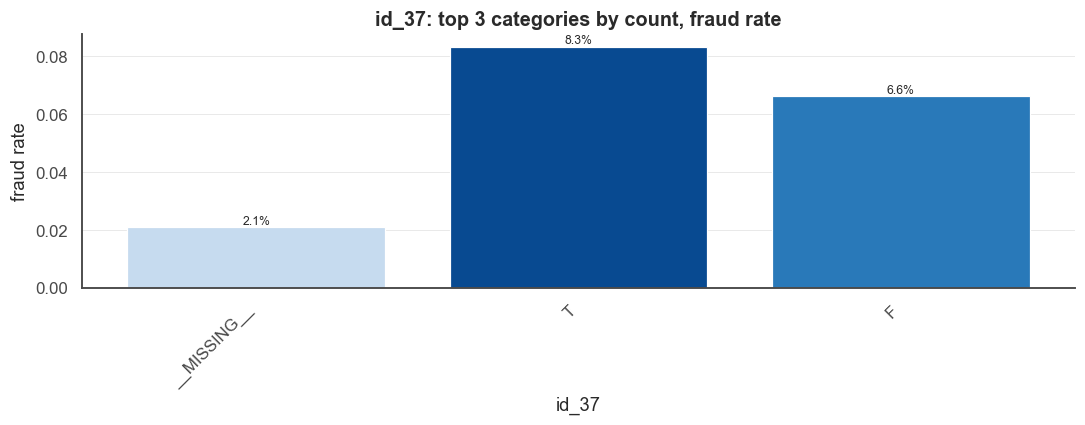

,id_37,count,fraud_rate
0,__MISSING__,449555,0.021001
1,T,110452,0.083312
2,F,30533,0.066158


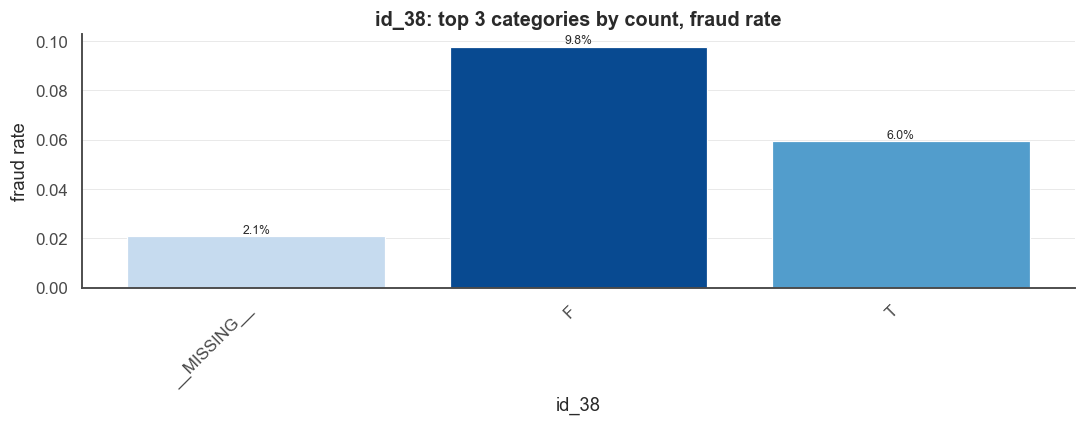

,id_38,count,fraud_rate
0,__MISSING__,449555,0.021001
1,F,73922,0.097792
2,T,67063,0.059541


In [101]:
def plot_cat_top(df, col, target="isFraud", top=10, min_size=2000):
    if col not in df.columns:
        print(f"[skip] {col} not found")
        return

    tmp = df[[col, target]].copy()
    tmp[col] = tmp[col].fillna("__MISSING__").astype(str)

    #same idea as top_profile above, it counts rows and fraud rate per category, but here it also plots it as a bar chart
    stat = (tmp.groupby(col)[target]
               .agg(count="size", fraud_rate="mean")
               .sort_values("count", ascending=False))

    #drops small categories to avoid one or two random fraud cases making a rare category look falsely risky
    stat = stat[stat["count"] >= min_size].head(top).reset_index()

    if stat.empty:
        print(f"[skip] {col}: no categories with count >= {min_size}")
        return

    #color each bar by its own fraud rate -- darker blue bars are riskier categories
    norm = plt.Normalize(stat["fraud_rate"].min(), stat["fraud_rate"].max())
    colors = plt.cm.Blues(0.25 + 0.65 * norm(stat["fraud_rate"]))

    fig, ax = plt.subplots(figsize=(10, 4))
    bars = ax.bar(stat[col], stat["fraud_rate"], color=colors, edgecolor="white", linewidth=0.8)

    #print the fraud rate above each bar so exact values don't require hovering
    for bar, rate in zip(bars, stat["fraud_rate"]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{rate:.1%}",
                 ha="center", va="bottom", fontsize=8, color="#2A2A2A")

    ax.set_xticks(range(len(stat)))
    ax.set_xticklabels(stat[col], rotation=45, ha="right")
    ax.set_title(f"{col}: top {len(stat)} categories by count, fraud rate")
    ax.set_ylabel("fraud rate"); ax.set_xlabel(col)
    ax.grid(axis="x")
    sns.despine()
    plt.tight_layout()
    plt.show()

    display(stat)
#columns
for c in ["ProductCD","card4","card6",
    "P_emaildomain","R_emaildomain",
    "DeviceType","DeviceInfo","id_31","id_33","id_34","id_35","id_36","id_37","id_38"]:
    plot_cat_top(train, c, top = 10, min_size = 2000)

The results show clear category-level risk differences; for example, `ProductCD = C`, `card6 = credit`, and some `email`/`browser`/`ID` groups have higher fraud rates than others), while missing is often both common and lower-risk on average.

This shows a strong categorical signal in the data and supports using careful encoding plus rare-category handling in later modeling.

#### Categorical Profiles (Product & Card Families)
top values with fraud rate grouped-by summaries for the most important categoricals

In [102]:
cat_cols = [
    "ProductCD","card4","card6",
    "P_emaildomain","R_emaildomain",
    "DeviceType","DeviceInfo","id_31","id_33","id_34","id_35","id_36","id_37","id_38"
]
cat_cols = [c for c in cat_cols if c in train.columns]

for col in cat_cols:
    t = train.assign(val = train[col].fillna("__MISSING__"))
    out = (
        t.groupby("val")["isFraud"]
        #fraud_sum is the raw count of fraud cases in that category, useful alongside fraud_rate since a high rate on very few cases is less reliable
        .agg(size = "count", fraud_rate = "mean", fraud_sum = "sum")
        .sort_values("size", ascending = False)
        .head(12)
        .reset_index()
        .rename(columns = {"val": col})
    )
    print(f"\n=== {col}: top categories ===")
    display(out)


=== ProductCD: top categories ===


,ProductCD,size,fraud_rate,fraud_sum
0,W,439670,0.020399,8969
1,C,68519,0.116873,8008
2,R,37699,0.037826,1426
3,H,33024,0.047662,1574
4,S,11628,0.058996,686



=== card4: top categories ===


,card4,size,fraud_rate,fraud_sum
0,visa,384767,0.034756,13373
1,mastercard,189217,0.034331,6496
2,american express,8328,0.028698,239
3,discover,6651,0.077282,514
4,__MISSING__,1577,0.025999,41



=== card6: top categories ===


...

,id_36,size,fraud_rate,fraud_sum
0,__MISSING__,449555,0.021001,9441
1,F,134066,0.081885,10978
2,T,6919,0.035265,244



=== id_37: top categories ===


,id_37,size,fraud_rate,fraud_sum
0,__MISSING__,449555,0.021001,9441
1,T,110452,0.083312,9202
2,F,30533,0.066158,2020



=== id_38: top categories ===


,id_38,size,fraud_rate,fraud_sum
0,__MISSING__,449555,0.021001,9441
1,F,73922,0.097792,7229
2,T,67063,0.059541,3993


These tables surface high-impact categories, data sparsity, and missingness patterns. Later, frequency encoding will likely be useful. They also guide feature selection and safe preprocessing.

#### Core numeric correlation heatmap
Pairwise Pearson correlations among selected core numeric features after median imputation.

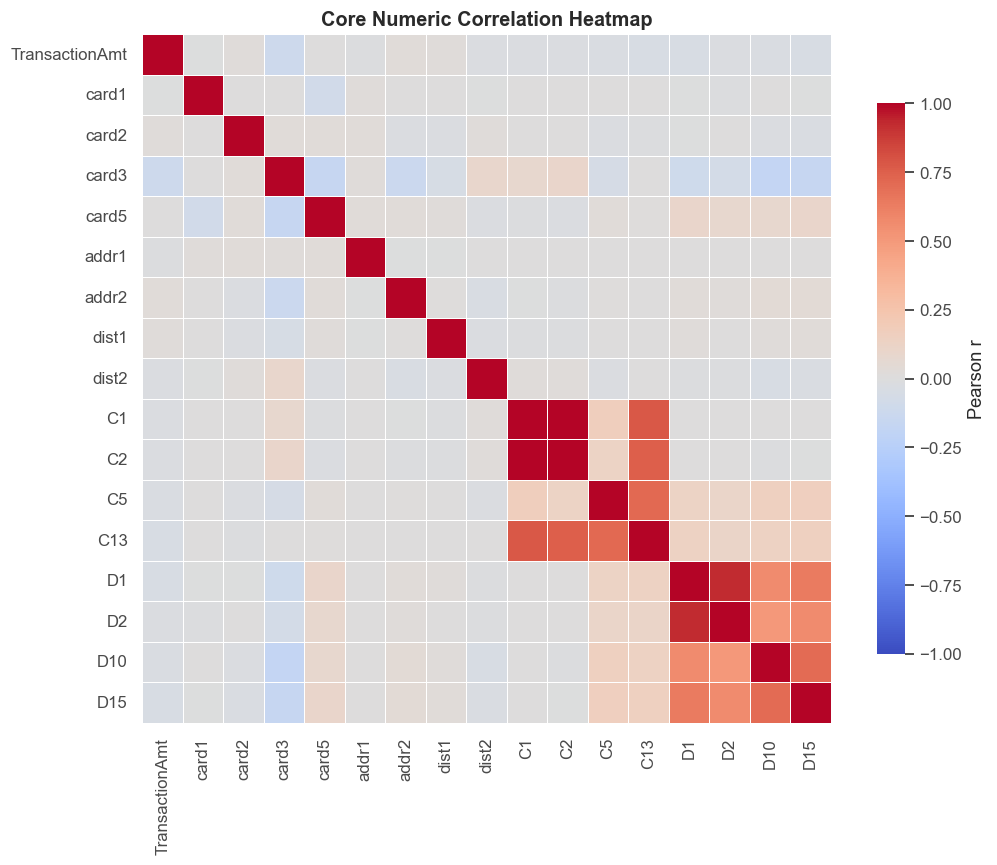

C1     C2       0.995089
D1     D2       0.925464
C1     C13      0.774603
C2     C13      0.751221
C5     C13      0.717509
D10    D15      0.708108
D1     D15      0.636458
D2     D15      0.567743
D1     D10      0.567605
D2     D10      0.507729
card3  D10      0.177009
C1     C5       0.165862
C5     D15      0.162779
card3  card5    0.159321
       D15      0.159022
C13    D15      0.153335
C5     D10      0.151295
C13    D10      0.140357
       D1       0.137307
C5     D1       0.132027
Name: pearson_r, dtype: float64

In [105]:
core_num = [
    "TransactionAmt",
    "card1", "card2", "card3", "card5",
    "addr1", "addr2",
    "dist1", "dist2",
    "C1", "C2", "C5", "C13",
    "D1", "D2", "D10", "D15"
]
core_num = [c for c in core_num if c in train.columns]

#numeric frame and median-impute to compute stable pearson correlation
tmp = train[core_num].copy()
tmp = tmp.apply(pd.to_numeric, errors="coerce")
tmp = tmp.fillna(tmp.median(numeric_only=True))

corr = tmp.corr(method = "pearson")

plt.figure(figsize = (10, 8))
sns.heatmap(
    corr,
    cmap = "coolwarm",
    vmin = -1,
    vmax = 1,
    center = 0,
    square = True,
    linewidths = 0.4,
    cbar_kws = {"shrink": 0.8, "label": "Pearson r"}
)
plt.title("Core Numeric Correlation Heatmap")
plt.tight_layout()
plt.show()

#show strongest absolute correlations
#keeps only the upper triangle of the correlation matrix, so each pair of features is only counted once instead of twice
upper = corr.where(np.triu(np.ones(corr.shape), k = 1).astype(bool))
top_corr = (
    upper.stack()
         .rename("pearson_r")
         .abs()
         .sort_values(ascending=False)
         .head(20)
)
display(top_corr)

Most pairs are close to zero (light gray), which means many variables contribute different information. At the same time, a few clear correlation blocks appear:

- Very strong pair `C1` and `C2` (r ≈ 0.995), suggesting near-duplicate signal.
- Strong `C`-block cluster: `C1`/`C2`/`C13` and partially `C5` are strongly related (r around 0.72–0.77 for several pairs).
- Strong `D`-block cluster with `D1`, `D2`, `D10`, `D15` are strongly correlated (r roughly 0.51–0.93), indicating shared temporal/behavioral structure.
- Moderate links with examples include `D10`-`D15` (r ≈ 0.71) and `D1`-`D15` (r ≈ 0.64).

Multicollinearity is concentrated in specific groups (eg `C` and `D` blocks). For modeling, this supports using regularization or feature selection/dimensionality reduction to avoid redundant features while preserving signal.

#### Scatter vs time (example of "TransactionAmt")

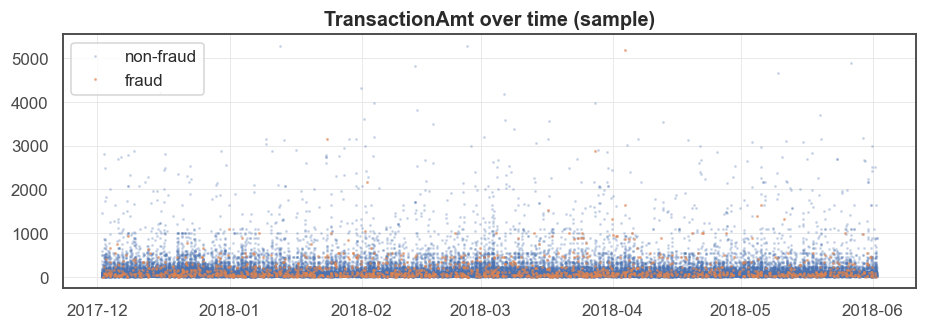

In [106]:
col = "TransactionAmt"   
tmp = train[[col, "isFraud", "event_time"]].dropna().sample(50000, random_state=0)
plt.figure(figsize = (10,3))
plt.plot(tmp.loc[tmp.isFraud==0, "event_time"], tmp.loc[tmp.isFraud==0, col], ".", alpha = 0.2, markersize = 2, label = "non-fraud")
plt.plot(tmp.loc[tmp.isFraud==1, "event_time"], tmp.loc[tmp.isFraud==1, col], ".", alpha = 0.5, markersize = 2, label = "fraud")
plt.title(f"{col} over time (sample)")
plt.legend(); plt.show() 

The plot above shows a 50k random sample of `TransactionAmt` over `event_time`, split by class. 
- most transactions cluster below ~1,000 with occasional spikes to several thousands;
- fraud points in orange appear across the range but include more high-amount outliers than non-fraud.

There is not a single shock period, rather the level and spread fluctuate over weeks, suggesting both seasonal effects and sporadic high-value bursts that may matter for drift and thresholding later.

### Fraud Monitoring Insights

#### Toy cumulative precision curve (amount as score)
All transactions sorted by a toy score that is just `TransactionAmt` ranked from high to low, then sweep a growing alert budget K and plot cumulative precision@K. 

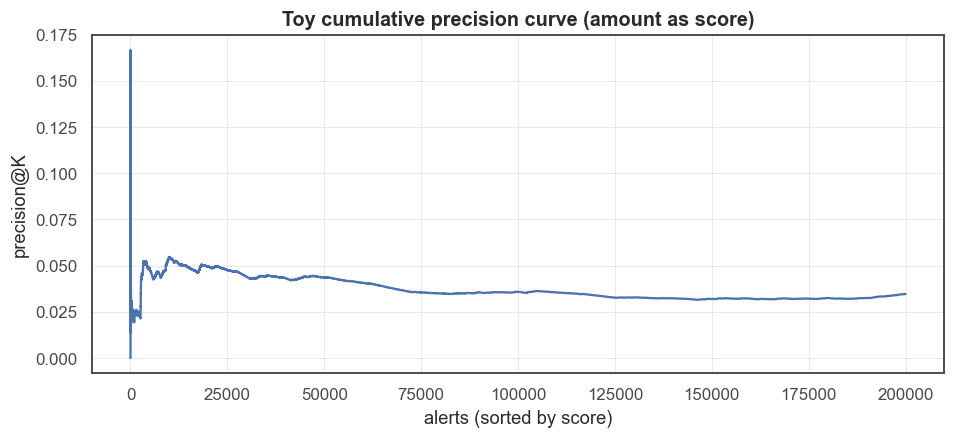

In [107]:
toy = df_s[["TransactionAmt","isFraud"]].dropna().copy()
#TransactionAmt into a percentile score, so the highest amounts get the highest "risk" score in this toy example
toy["score"] = toy["TransactionAmt"].rank(pct = True) 
toy = toy.sort_values("score", ascending = False)
toy["cum_alerts"] = range(1, len(toy)+1)
toy["cum_frauds"] = toy["isFraud"].cumsum()
#precision@k means out of the top-k alerts by this toy score, what share were actually fraud
toy["precision_at_k"] = toy["cum_frauds"] / toy["cum_alerts"]

ax = toy.plot(x = "cum_alerts", y = "precision_at_k", figsize = (10,4), legend = False)
ax.set_xlabel("alerts (sorted by score)"); ax.set_ylabel("precision@K")
ax.set_title("Toy cumulative precision curve (amount as score)"); plt.show()

The sharp spike at the very beginning means the very first few alerts (highest amounts) are much more likely to be fraud than average, but precision quickly decays and gradually approaches the global base rate (~3-4%). 

This is only to illustrate the top-K alerting metric and shows that amount alone provides limited lift, so richer features and real ranking models, not just a single raw column, will be needed in the next stages, evaluated on a strictly time-aware split, not a random one.

#### Cumulative recall@K toy (amount as score) to pair with your precision@K
Transactions sorted by `TransactionAmt` with highest first, then walked down the list and computed the recall@K after each additional alert (how many frauds are captured so far divided by total frauds).

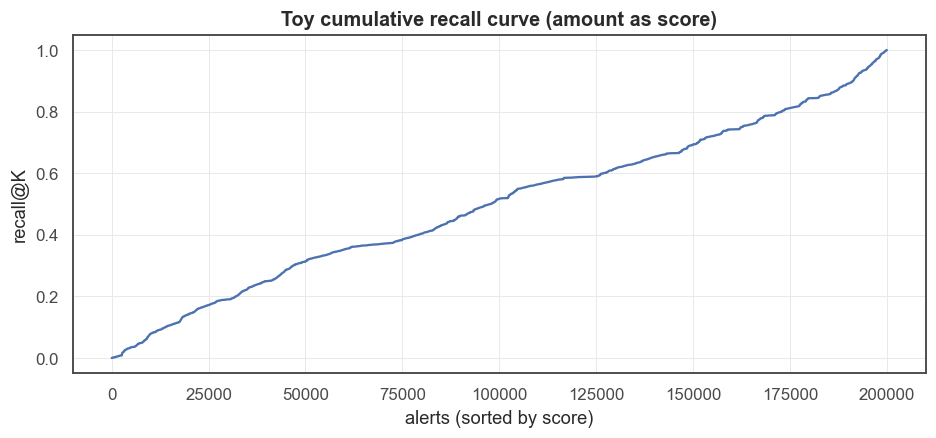

In [108]:
toy = df_s[["TransactionAmt","isFraud"]].dropna().copy()
toy["score"] = toy["TransactionAmt"].rank(pct = True)  # high = high amount
toy = toy.sort_values("score", ascending = False)
toy["cum_alerts"] = range(1, len(toy)+1)
toy["cum_frauds"] = toy["isFraud"].cumsum()
#recall@k means out of all fraud in the sample, what share has been caught by the top-k alerts so far
toy["recall_at_k"] = toy["cum_frauds"] / toy["isFraud"].sum()
toy.plot(x = "cum_alerts", y = "recall_at_k", figsize = (10,4), legend = False,
         title = "Toy cumulative recall curve (amount as score)")
plt.xlabel("alerts (sorted by score)"); plt.ylabel("recall@K"); plt.show()

The x-axis is the number of alerts (top-K by amount). The y-axis is the fraction of all frauds captured up to that K.

Using amount alone as a score recovers frauds steadily but slowly; recall grows almost linearly.
This is a baseline, a real model should curve upward faster (higher recall for the same K).

#### Numeric Distributions - C Block (fraud by deciles)

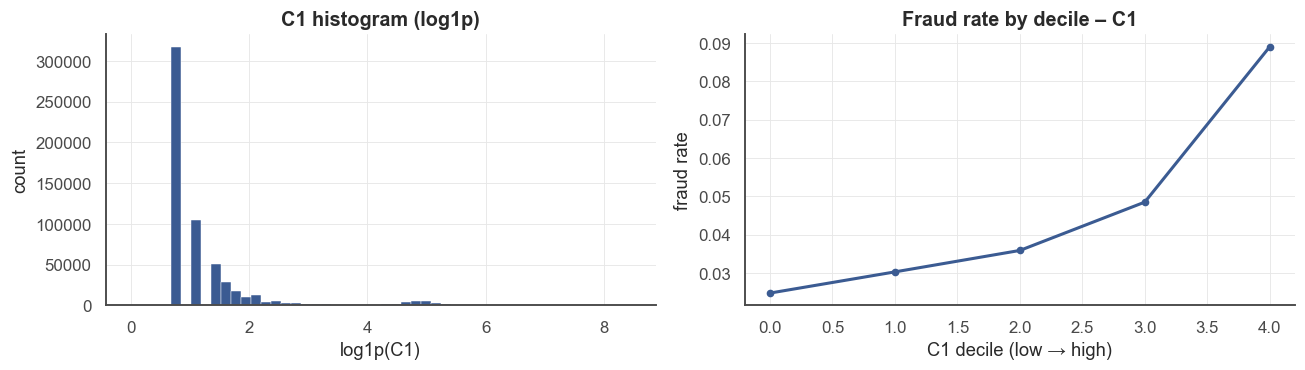

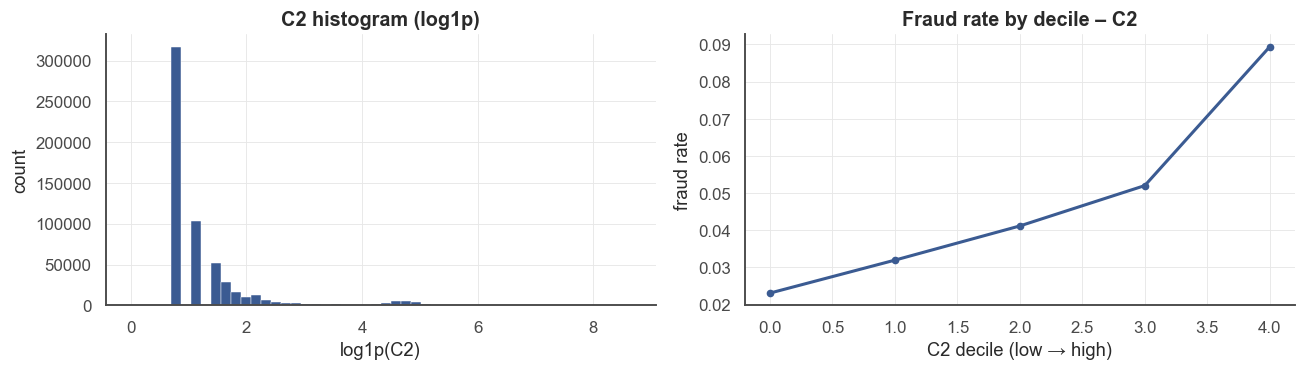

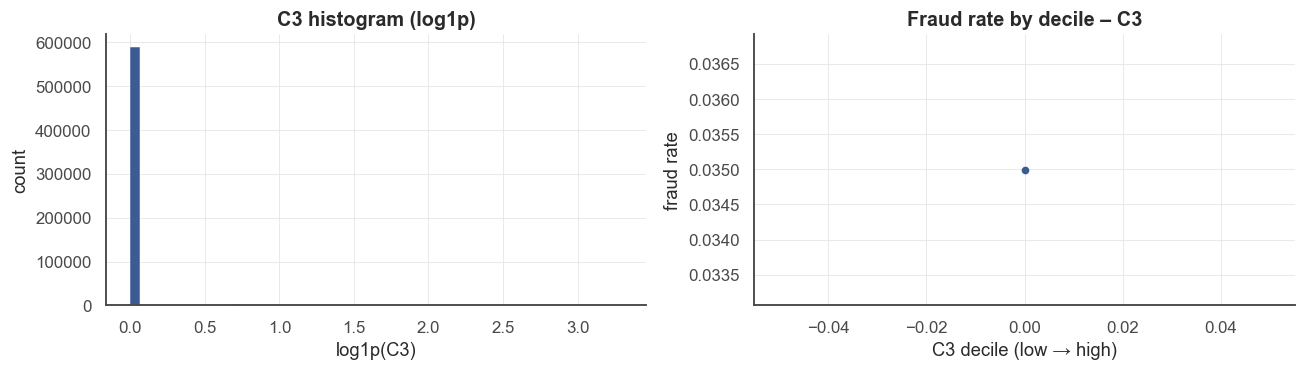

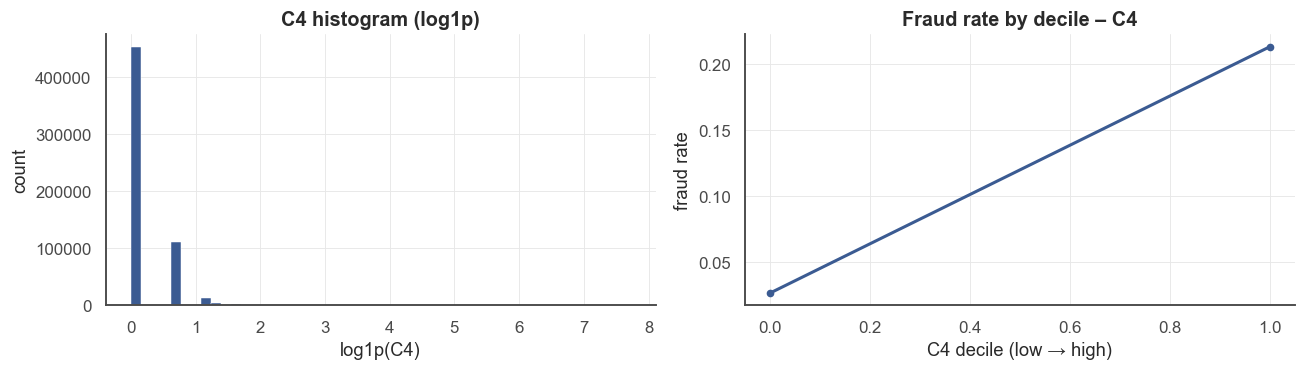

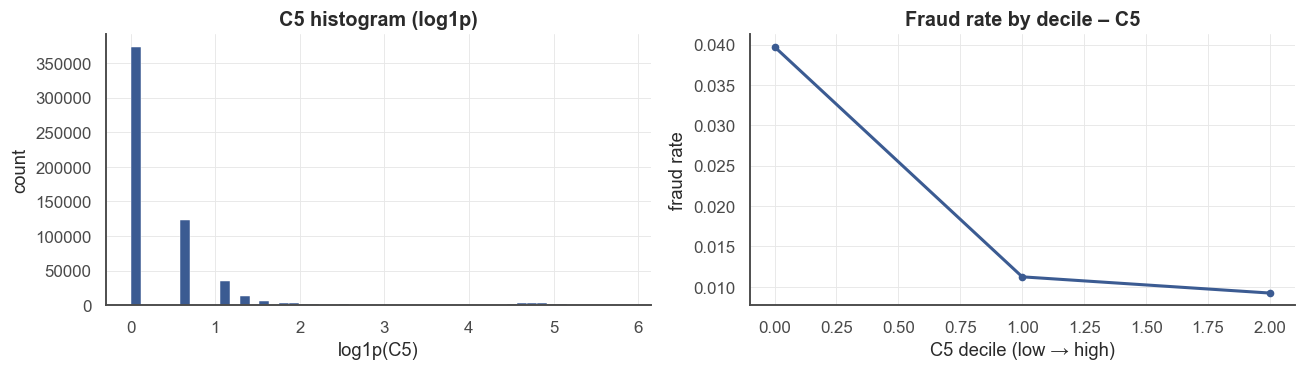

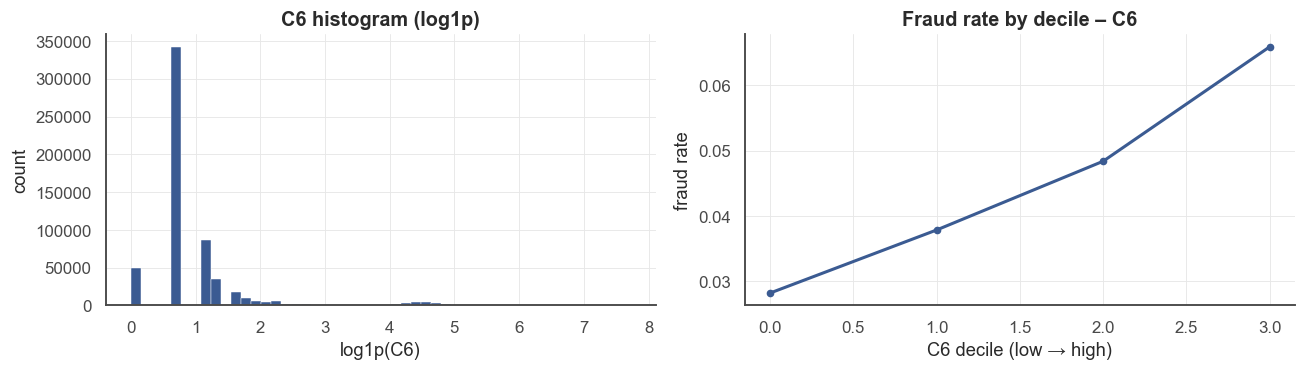

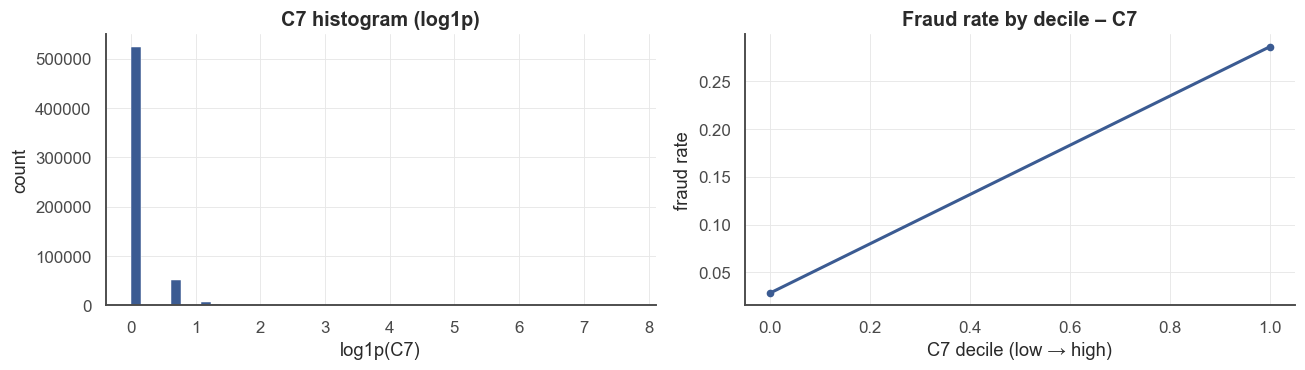

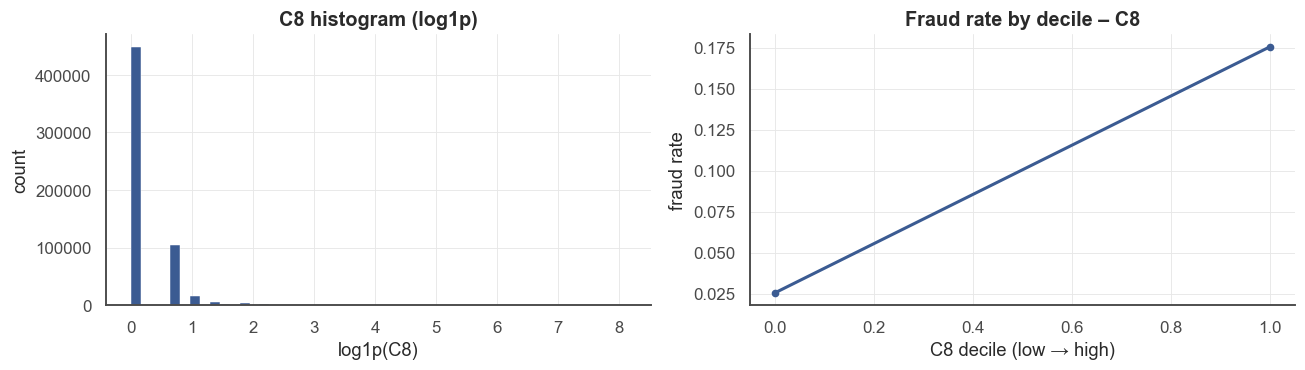

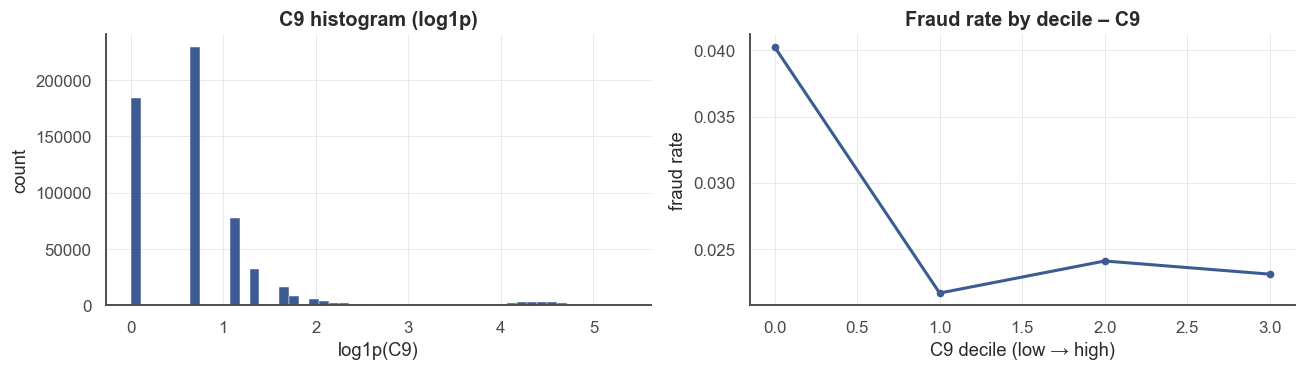

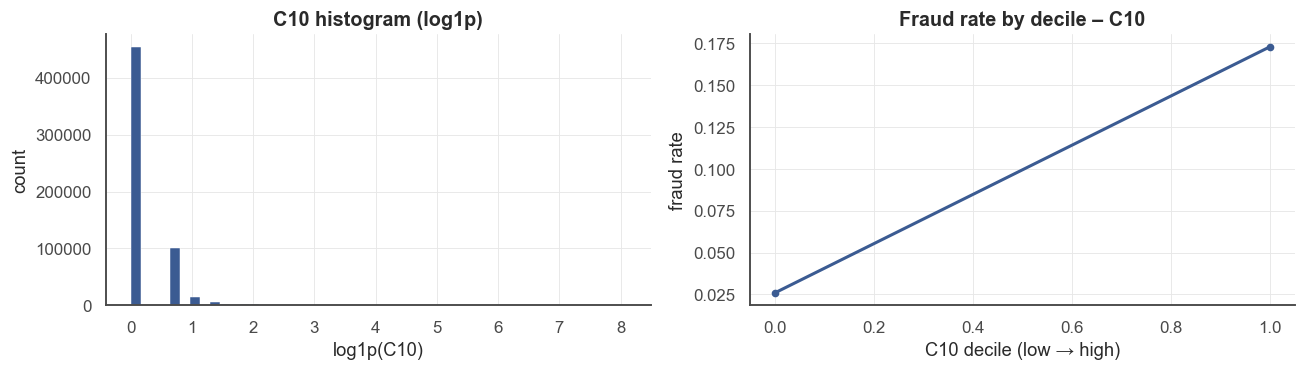

In [109]:
C_cols = [c for c in train.columns if c.startswith("C")]
C_cols = [c for c in C_cols if train[c].dtype.kind in "biufc"]

def plot_deciles(col):
    s = train[col]
    try:
        #splits the column into 10 equal-sized groups by value, dropping duplicate bin edges if a lot of rows share the same value
        q = pd.qcut(s, 10, duplicates="drop")
    except Exception:
        return
    fr = train.groupby(q)["isFraud"].mean()

    fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))

    #C-block features are heavily right-skewed (like TransactionAmt was), so log1p makes the shape readable
    log_vals = np.log1p(s.dropna())
    log_vals = log_vals[np.isfinite(log_vals)]
    log_vals.hist(bins=50, ax=ax[0], color=ACCENT, edgecolor="white", linewidth=0.3)
    ax[0].set_title(f"{col} histogram (log1p)")
    ax[0].set_xlabel(f"log1p({col})"); ax[0].set_ylabel("count")

    ax[1].plot(range(len(fr)), fr.values, color=ACCENT, linewidth=2, marker="o", markersize=4)
    ax[1].set_title(f"Fraud rate by decile \u2013 {col}")
    ax[1].set_xlabel(f"{col} decile (low \u2192 high)"); ax[1].set_ylabel("fraud rate")

    sns.despine()
    plt.tight_layout()
    plt.show()

for c in C_cols[:10]:  #preview first 10
    plot_deciles(c)

The C-block features are highly right-skewed.
Despite similar histogram shapes, the fraud-rate-by-decile curves show different behavior across features.

- Several `C` features (eg `C1`, `C2`, `C6`, `C7`, `C8`, `C10`) show increasing fraud rate in higher value bins, suggesting larger C-values are associated with higher fraud risk.
- Some features are flatter or non-monotonic (eg `C5`, `C9`), indicating weaker or more complex relationships.
- A few plots have fewer than 10 bins because many repeated values force qcut(..., duplicates="drop") to merge bins.

This is most extreme for C3, which is almost entirely zero and collapses to a single bin, and affects C4, C7, C8, and C10, which resolve to only 2 bins instead of 10." 

So C features carry useful signal, but it is different from feature to feature. I keep them for modeling, scale them since they are heavily skewed, and check later that they stay stable over time.

#### Numeric Distributions - D Block (fraud by deciles)

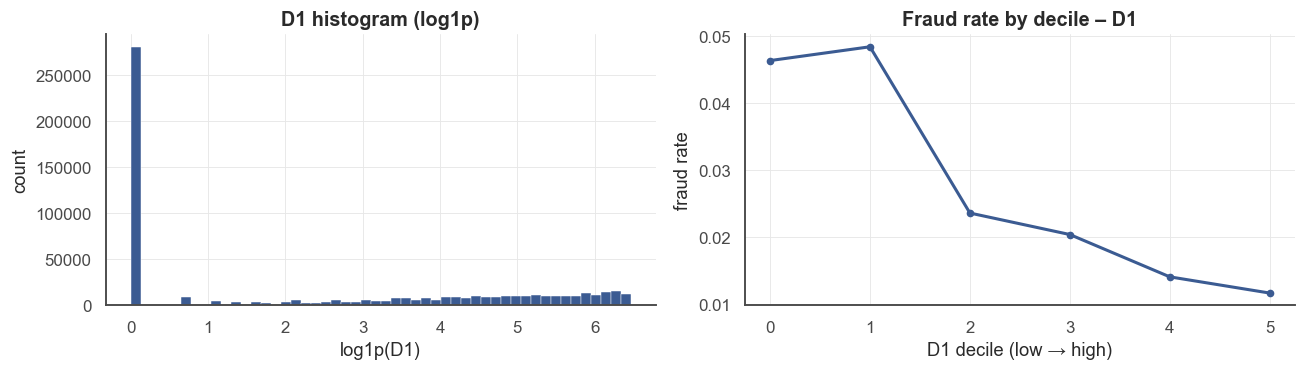

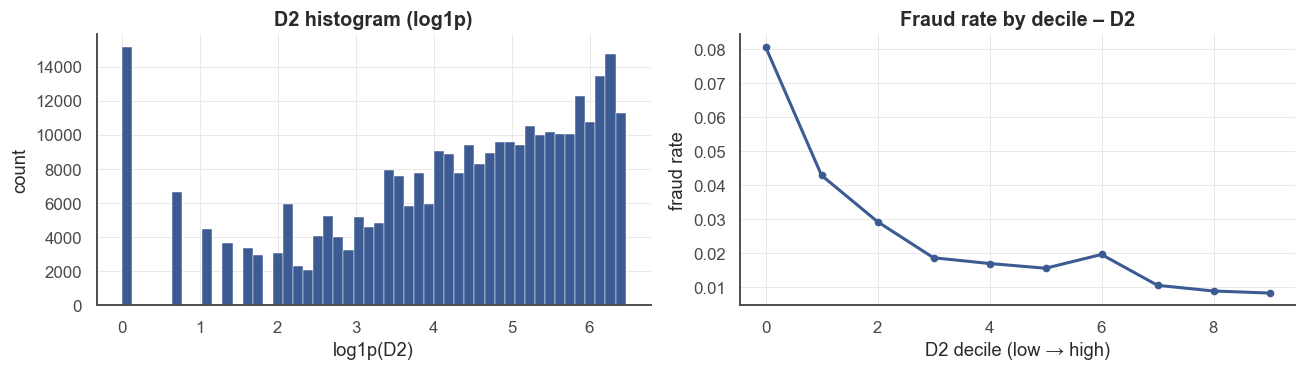

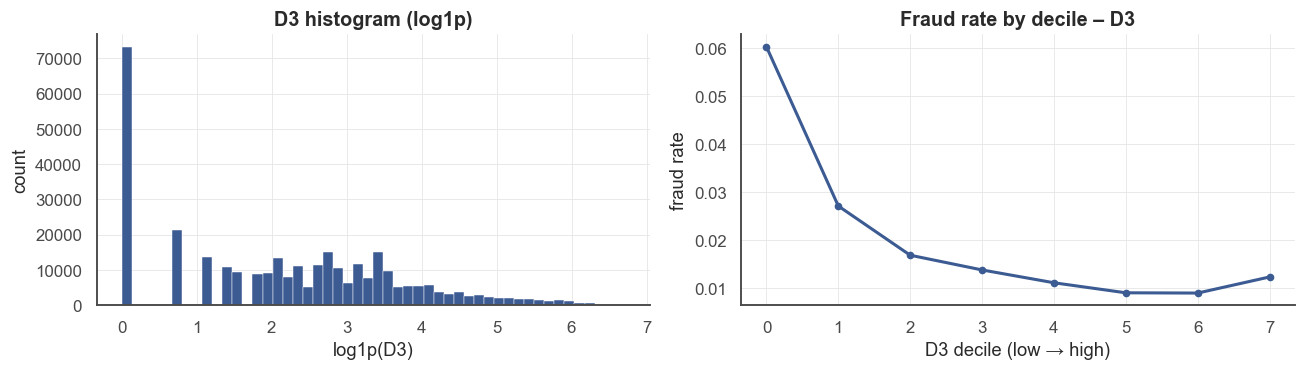

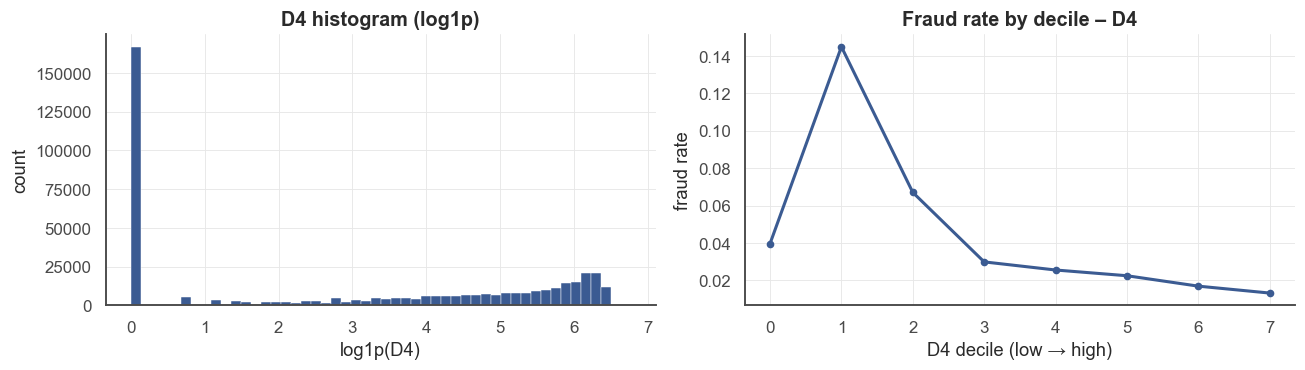

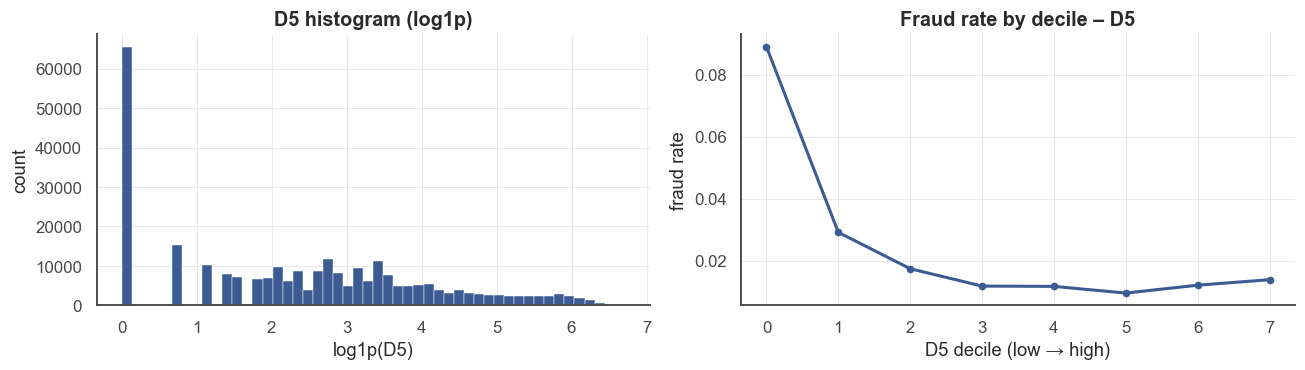

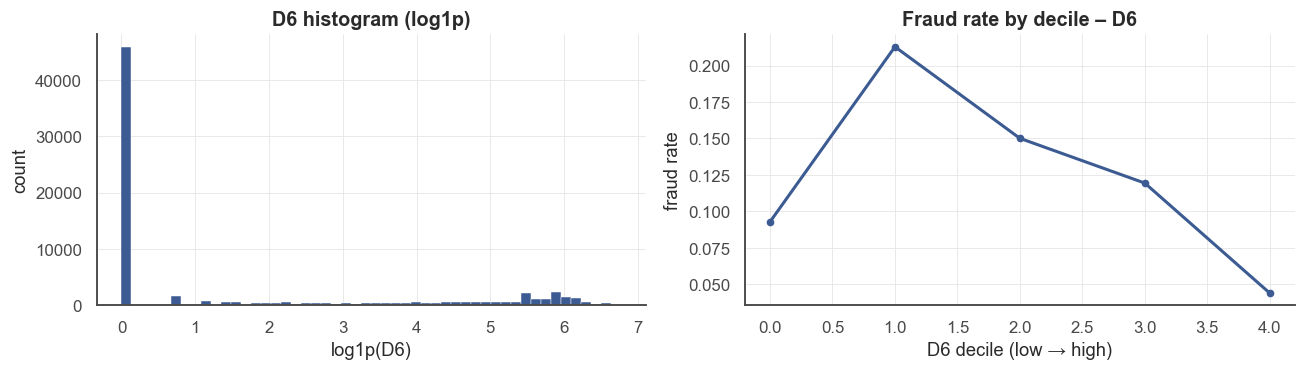

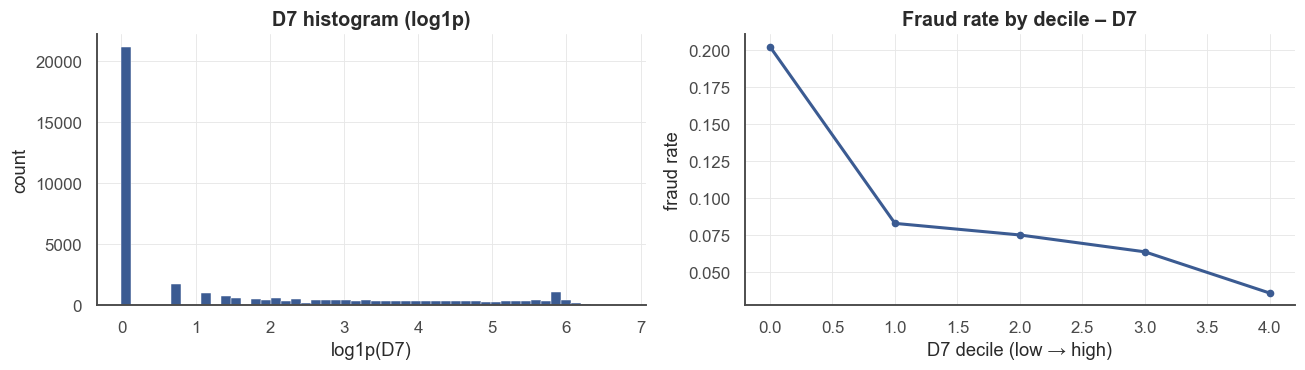

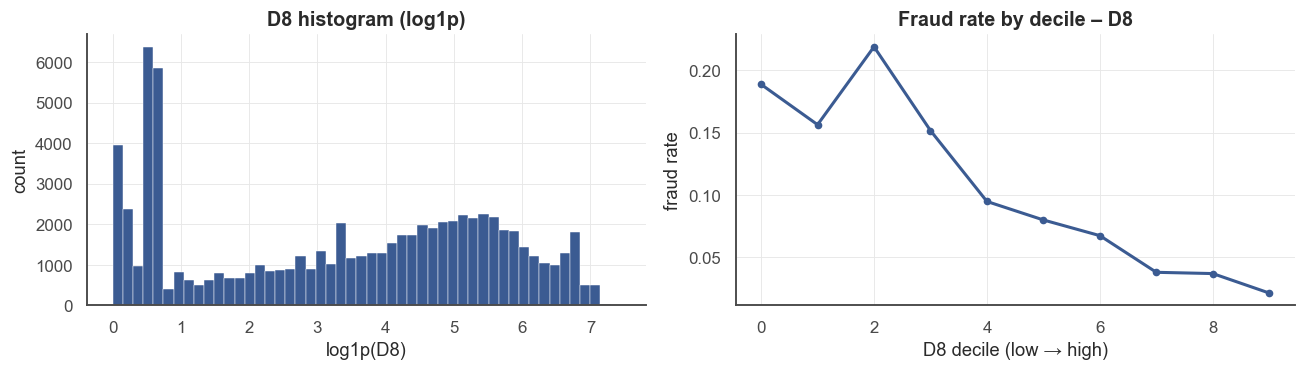

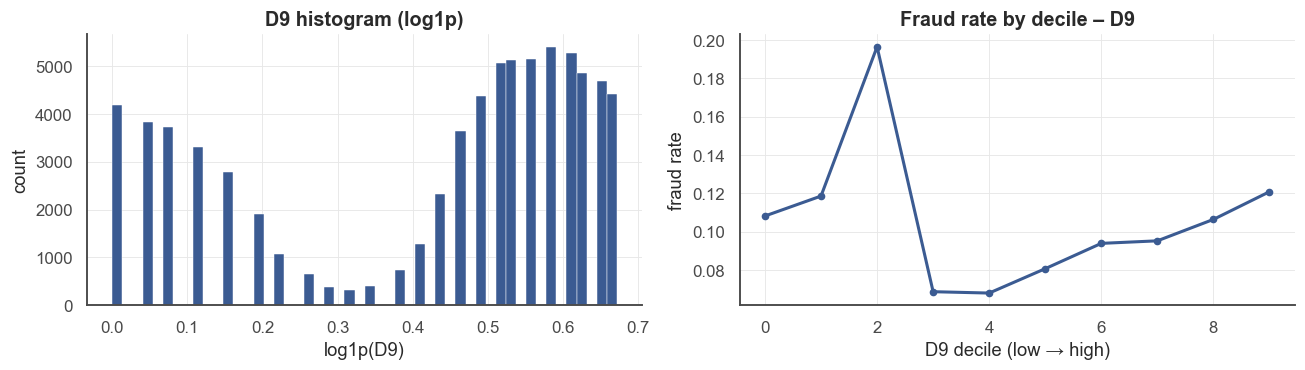

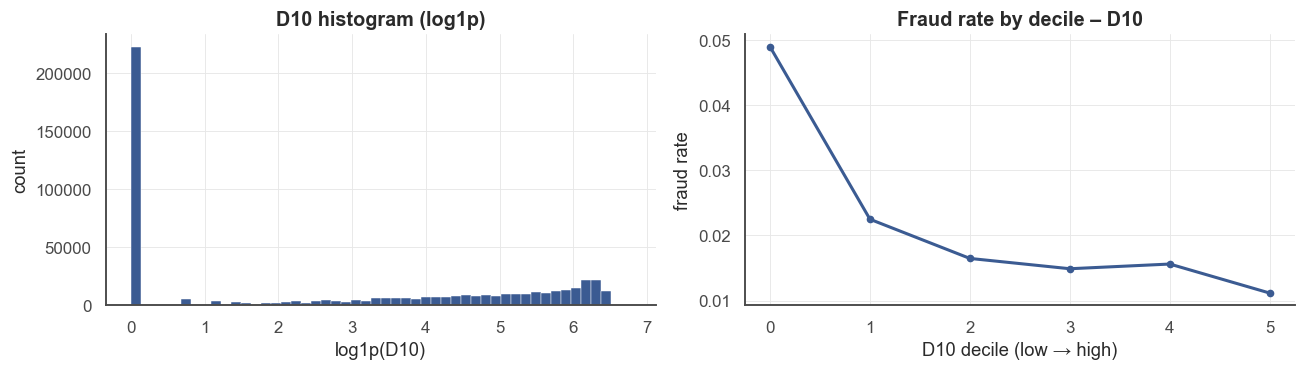

In [110]:
D_cols = [c for c in train.columns if c.startswith("D")]
D_cols = [c for c in D_cols if train[c].dtype.kind in "biufc"]

def plot_deciles(col):
    s = train[col]
    try:
        #splits the column into 10 equal-sized groups by value, dropping duplicate bin edges if a lot of rows share the same value
        q = pd.qcut(s, 10, duplicates="drop")
    except Exception:
        return
    fr = train.groupby(q)["isFraud"].mean()

    fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))

    #D-block features (days since X) are heavily right-skewed too, so log1p makes the shape readable.
    #a few rows have small negative values (likely data noise), which turn into -inf after log1p and
    #aren't removed by dropna() -- filter those out explicitly with isfinite
    log_vals = np.log1p(s.dropna())
    log_vals = log_vals[np.isfinite(log_vals)]
    log_vals.hist(bins=50, ax=ax[0], color=ACCENT, edgecolor="white", linewidth=0.3)
    ax[0].set_title(f"{col} histogram (log1p)")
    ax[0].set_xlabel(f"log1p({col})"); ax[0].set_ylabel("count")

    ax[1].plot(range(len(fr)), fr.values, color=ACCENT, linewidth=2, marker="o", markersize=4)
    ax[1].set_title(f"Fraud rate by decile \u2013 {col}")
    ax[1].set_xlabel(f"{col} decile (low \u2192 high)"); ax[1].set_ylabel("fraud rate")

    sns.despine()
    plt.tight_layout()
    plt.show()

for c in D_cols[:10]:  #first 10
    plot_deciles(c)

The `D`-block features are mostly highly right-skewed.

- For several features (`D1`, `D2`, `D3`, `D5`, `D7`, `D8`, `D10`), fraud rate is highest in lower-value bins and tends to decline as values increase.
- Some features show local peaks or mixed behavior (for example `D4`, `D6`, `D9`), indicating interactions or threshold effects rather than simple monotonic trends.
- `D9` has a different shape and distribution from other `D` features and a more irregular fraud-rate profile.

So `D` features carry useful signal too, but the relationship with fraud is not the same shape for every feature. I will keep them, scale them to deal with the skew, and use models that can pick up non-linear patterns instead of assuming a straight-line relationship.

#### Missingness as signal summary (fraud when missing vs present)
Comparison of fraud rates in two groups for each feature, with rows where the value is missing vs rows where it is present.

In [111]:
res = []
cols = [c for c in train.columns if c not in ["isFraud","TransactionID","event_time"]]
for c in cols:
    m = train[c].isna()
    if m.mean() == 0: 
        continue
    #for each feature, compares the fraud rate in rows where the value is missing against rows where it is present
    res.append([c, m.mean(), train.loc[m,"isFraud"].mean(), train.loc[~m,"isFraud"].mean()])
miss_sig = (pd.DataFrame(res, columns = ["feature","missing_share","fraud_when_missing","fraud_when_present"])
              .sort_values("missing_share", ascending = False))
display(miss_sig.head(25))

,feature,missing_share,fraud_when_missing,fraud_when_present
397,id_24,0.991962,0.034587,0.084685
398,id_25,0.991310,0.034584,0.081255
380,id_07,0.991271,0.034570,0.082638
381,id_08,0.991271,0.034570,0.082638
394,id_21,0.991264,0.034571,0.082574
399,id_26,0.991257,0.034573,0.082316
400,id_27,0.991247,0.034571,0.082414
396,id_23,0.991247,0.034571,0.082414
395,id_22,0.991247,0.034571,0.082414
8,dist2,0.936284,0.030623,0.099158


In this output, many highly sparse features (`id_*`, `D*`, `dist2`) have much higher fraud rates when present than when missing (for example `D7`, `D13`, `D14`, `D12`). So value observed itself may indicate a different risk profile. It gives understanding that missing values should not been treated as harmless noise. Missingness is not random for many variables and can carry predictive signal.

#### Loss share by amount decile
The split of transactions into 10 equal-frequency amount bins and reports, such as count (transactions in bin), fraud_rate (share of fraud in that bin), loss_share (share of total fraud amount contributed by that bin).

In [112]:
tmp = train[["TransactionAmt","isFraud"]].dropna()
tmp["amt_bin"] = pd.qcut(tmp["TransactionAmt"], 10, duplicates = "drop")
g = tmp.groupby("amt_bin").agg(
    count = ("isFraud","size"),
    fraud_rate = ("isFraud","mean"),
    #sums TransactionAmt only for the fraud rows in each bin, so this measures fraud dollars, not just fraud count
    loss_share = ("TransactionAmt", lambda s: s[tmp.loc[s.index,"isFraud"]==1].sum())
).reset_index()
g["loss_share"] = g["loss_share"] / g["loss_share"].sum()
display(g)

,amt_bin,count,fraud_rate,loss_share
0,"(0.25, 25.95]",59511,0.055889,0.017682
1,"(25.95, 35.95]",61650,0.032052,0.019785
2,"(35.95, 49.0]",65116,0.032250,0.029600
3,"(49.0, 57.95]",59647,0.019431,0.019876
4,"(57.95, 68.769]",49346,0.028513,0.027964
5,"(68.769, 100.0]",73349,0.036170,0.074367
6,"(100.0, 117.0]",72079,0.019742,0.051925
7,"(117.0, 159.95]",32399,0.043026,0.064880
8,"(159.95, 275.293]",58390,0.038037,0.150187
9,"(275.293, 31937.391]",59053,0.050870,0.543735


The highest amount decile contributes a disproportionately large share of total fraud loss (~54%), far above any other bin, while lower/mid bins contribute much less individually. 

So even when fraud rate is not highest at large amounts, that is where most of the fraud money actually is. That is a good reason to keep `TransactionAmt` as a feature, so the model can pick up on this pattern when ranking transactions

### EDA conclusions for next stages

Main findings:
- Fraud behavior is time-dependent, so chronological validation is required.
- Missingness is structured and often informative (not random noise).
- Several categorical groups (device/email/card) show clear risk separation.
- Numeric feature blocks contain correlated clusters, suggesting dimensionality reduction or careful feature selection.

These findings are carried to the Feature Audit and Preprocessing notebooks.

#### EDA Artifacts

In [113]:
from pathlib import Path
import json

ART = PROJECT_DIR / "artifacts"
ART.mkdir(parents = True, exist_ok = True)

#dataset schema snapshot
schema = pd.DataFrame({
    "feature": train.columns,
    "dtype": train.dtypes.astype(str).values,
    "missing_share": train.isna().mean().values,
    "n_unique": train.nunique(dropna = False).values
})
schema.to_csv(ART / "eda_schema_snapshot.csv", index = False)

#missingness summary
missing_summary = train.isna().mean().sort_values(ascending = False).rename("missing_share").reset_index()
missing_summary.columns = ["feature", "missing_share"]
missing_summary.to_csv(ART / "eda_missingness_summary.csv", index = False)

#target balance
target_balance = train["isFraud"].value_counts(normalize = True).rename("share").reset_index()
target_balance.columns = ["isFraud", "share"]
target_balance.to_csv(ART / "eda_target_balance.csv", index = False)

#time split cutoffs
if "event_time" in train.columns:
    #saves the same q60/q80 cutoffs used for the chronological split, so later notebooks can reuse the exact same train/val/holdout boundaries
    split_cfg = {
        "event_time_min": str(pd.to_datetime(train["event_time"]).min()),
        "event_time_max": str(pd.to_datetime(train["event_time"]).max()),
        "q60": str(pd.to_datetime(train["event_time"]).quantile(0.60)),
        "q80": str(pd.to_datetime(train["event_time"]).quantile(0.80)),
    }
    (ART / "split_config.json").write_text(json.dumps(split_cfg, indent = 2))

print("EDA artifacts saved to:", ART)

EDA artifacts saved to: /Users/kravchan/Desktop/Supervised Research/project/artifacts


##### End of notebook